significant trials, significant GT \n
plot trials based on significance or sleep state

In [337]:
import os
import numpy as np
import mne
import imageio
import h5py
# import scipy.fftpack
import matplotlib
import pywt
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
# from scipy import signal
from matplotlib.colors import ListedColormap
import time
import seaborn as sns

# import scipy.io as sio
# from scipy.integrate import simps
import pandas as pd
# from scipy import fft
import matplotlib.mlab as mlab
import sys
import matplotlib as mpl
sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis\py_functions')
import NMF_funcs as NMFf
import significant_connections as SCF
from scipy.stats import norm
import LL_funcs
from scipy.stats import norm
from tkinter import filedialog
from tkinter import *
import ntpath
import supp_sleep_CCEP_figures as fig_sleep
root = Tk()
root.withdraw()
import math
import scipy
from scipy import signal
import pylab
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import platform
from glob import glob
from scipy.io import savemat
import scipy.cluster.hierarchy as spc
from scipy.spatial import distance
from sklearn.cluster import KMeans
import h5py
import basic_func as bf
from scipy.integrate import simps
from numpy import trapz
#import IO_func as IOF
#import BM_func as BMf
import tqdm
from matplotlib.patches import Rectangle
from pathlib import Path
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab
import BM_plots as BMp
import freq_funcs as ff
import CCEP_plot
import supp_CCEP_figures as CCEP_supp
import random
import math
from sklearn.metrics import cohen_kappa_score, jaccard_score, accuracy_score
dist_groups = np.array([[0, 30], [30, 60], [60, 120]])
dist_labels = ['local (<30 mm)', 'short (<60mm)', 'long']
Fs = 500
dur = np.zeros((1, 2), dtype=np.int32)
t0 = 1
dur[0, 0] = -t0
dur[0, 1] = 3

folder = 'BrainMapping'
# dur[0,:]       = np.int32(np.sum(abs(dur)))
x_ax = np.arange(dur[0, 0], dur[0, 1], (1 / Fs))
color_elab = np.zeros((3, 3))
color_elab[0, :] = np.array([31, 78, 121]) / 255
color_elab[1, :] = np.array([189, 215, 238]) / 255
color_elab[2, :] = np.array([0.256, 0.574, 0.431])
cwd = os.getcwd()
color_sleep = ['#808080', '#145da0', '#ff1919']
label_sleep = ['Wake', 'NREM', 'REM']
color_dist = ['0000FF','#0076C4','#00DD91']
import CCEP_func

In [251]:
cond_folder = 'CR'
path_gen_base = sub_path + '\Patients'

In [252]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [253]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

In [255]:
subjs = ["EL010", "EL011","EL012","EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024","EL026", "EL027", "EL028"]
len(subjs)

15

In [352]:
con_all['DI_abs'] = 0
con_all.loc[abs(con_all.DI)>0.05,'DI_abs'] = 1

In [353]:
np.mean(con_all['DI_abs'])

0.7857570848405495

In [339]:
import load_summary as ls
con_all = ls.get_connections(subjs, sub_path)
con_all = con_all[(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
con_all['Con_ID'] = con_all.groupby(['Subj', 'Stim', 'Chan']).ngroup()

In [257]:
con_all['Sig_Con'] = 0
con_all.loc[(con_all.Sig>0)&(con_all.True_peak==1)&(con_all.Num_sig_trial>10), 'Sig_Con'] = 1

In [261]:
data_Con_prob = con_all[['Con_ID', 'StimR', 'ChanR', 'Sig_Con', 'd']].reset_index(drop=True)
data_Con_prob = data_Con_prob[(np.isin(data_Con_prob.StimR, regions_all))&(np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)

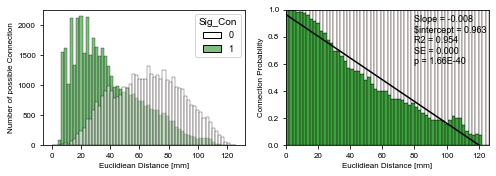

In [328]:
fig = plt.figure(figsize=(8,2.5))
gs         = fig.add_gridspec(1,2) #, width_ratios=[5,3]

ax_count = fig.add_subplot(gs[0,0])
sns.histplot(x='d', hue='Sig_Con', data= data_Con_prob, multiple='layer', ax = ax_count,bins = 60, palette = ['snow','green'])
ax_count.set_ylabel('Number of possible Connection')
ax_count.set_xlabel('Euclidiean Distance [mm]')

ax_ratio = fig.add_subplot(gs[0,1])
sns.histplot(x='d', hue='Sig_Con', data= data_Con_prob, ax = ax_ratio, multiple='fill', bins = 60, palette = ['snow','green'], legend = False)
ax_ratio.set_ylabel('Connection Probability')
ax_ratio.set_xlabel('Euclidiean Distance [mm]')
ax_ratio.plot(x_d, intercept+slope*x_d, color='k')
ax_ratio.set_ylim([0,1])
plt.text(80, 0.6, f'Slope = {slope:.3f}\n$intercept = {intercept:.3f}\nR2 = {r**2:.3f}\nSE = {se:.3f}\np = {p:.2E} ', fontsize = 9)    # Set titles and labels
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_count_ratio.svg'
plt.savefig(file)


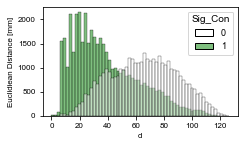

In [320]:
plt.figure(figsize=(3.5,2))
sns.histplot(x='d', hue='Sig_Con', data= data_Con_prob, multiple='layer', bins = 60, palette = ['white','green'])
plt.ylabel('Number of possible Connection')
plt.ylabel('Euclidiean Distance [mm]')
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_counts.svg'
plt.savefig(file)

In [299]:
x_d = np.linspace(0, np.max(data_Con_prob.d), 60)
y = intercept+slope*x_d/2

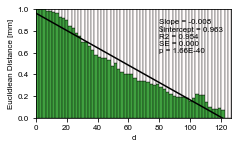

In [324]:
plt.figure(figsize=(3.5,2))
sns.histplot(x='d', hue='Sig_Con', data= data_Con_prob, multiple='fill', bins = 60, palette = ['snow','green'], legend = False)
plt.ylabel('Connection Probability')
plt.ylabel('Euclidiean Distance [mm]')
plt.plot(x_d, intercept+slope*x_d, color='k')
plt.ylim([0,1])
plt.text(80, 0.6, f'Slope = {slope:.3f}\n$intercept = {intercept:.3f}\nR2 = {r**2:.3f}\nSE = {se:.3f}\np = {p:.2E} ', fontsize = 8)    # Set titles and labels
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_ratio.svg'
plt.savefig(file)

In [303]:
# Cut 'peak_latency' into 20 bins and assign codes
data_Con_prob['d_bin'] = pd.cut(data_Con_prob['d'], bins=60)
data_Con_prob['d_bin_code'] = data_Con_prob['d_bin'].cat.codes

grouped = data_Con_prob.groupby(['d_bin_code', 'Sig_Con']).size().unstack(fill_value=0)
proportions = grouped.div(grouped.sum(axis=1), axis=0)

# Reset the index to make 'd_bin' a column again for easier readability
proportions.reset_index(inplace=True)


# Setup the linear regression model
X = proportions['d_bin_code'].values
y = proportions[1].values
# todo: show results
slope, intercept, r, p, se = scipy.stats.linregress(x_d, y)
print(slope, intercept, r**2, p, se)

-0.007988783866309204 0.9628774927608501 0.9541030661869851 1.6593406243259202e-40 0.0002300704625449944


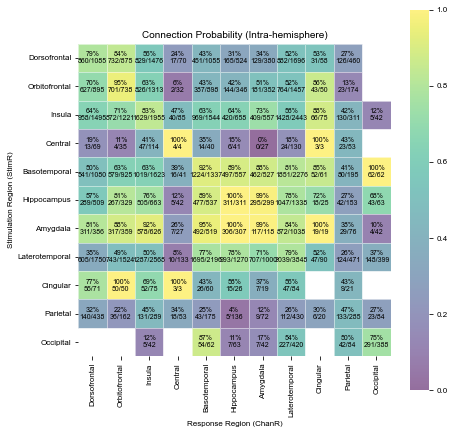

In [336]:
h = 0
data_Con_prob = con_all[['Con_ID', 'StimR', 'ChanR', 'Sig_Con', 'd', 'H']].reset_index(drop=True)
data_Con_prob = data_Con_prob[(data_Con_prob.H == h) & (np.isin(data_Con_prob.StimR, regions_all)) & (np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)

# Calculate the ratio of Sig_Con == 1 to the total number of connections for each pair of regions
heatmap_data = data_Con_prob.groupby(['StimR', 'ChanR'])['Sig_Con'].mean().unstack(fill_value=np.nan)

# Create a DataFrame with NaN values for missing labels
missing_labels = list(set(regions_all) - set(heatmap_data.index))
for lab in missing_labels:
    empty_array = pd.DataFrame([[np.max(data_Con_prob.Con_ID)+1, lab, lab, np.nan, np.nan, h]], columns=['Con_ID', 'StimR', 'ChanR', 'Sig_Con', 'd', 'H'])
    data_Con_prob = pd.concat([data_Con_prob, empty_array], 0)
data_Con_prob = data_Con_prob.reset_index(drop=True)

heatmap_data = data_Con_prob.groupby(['StimR', 'ChanR'])['Sig_Con'].mean().unstack(fill_value=np.nan)
heatmap_data = heatmap_data.loc[regions_all, regions_all]  # Reorder rows and columns

# Create the heatmap
plt.figure(figsize=(7,7))
ax =sns.heatmap(heatmap_data, annot=False, cmap='viridis', alpha=0.57, fmt='.2f', linewidths=0.5, xticklabels=regions_all, yticklabels=regions_all)
ax.set_aspect('equal')
plt.xlabel('Response Region (ChanR)')
plt.ylabel('Stimulation Region (StimR)')

# Annotate the heatmap with count values (percentage and actual ratio)
for i in range(len(regions_all)):
    for j in range(len(regions_all)):
        count_all = len(data_Con_prob[(data_Con_prob.Sig_Con>=0)&(data_Con_prob.StimR==regions_all[i])&(data_Con_prob.ChanR==regions_all[j])])
        if count_all>0:
            count = len(data_Con_prob[(data_Con_prob.Sig_Con==1)&(data_Con_prob.StimR==regions_all[i])&(data_Con_prob.ChanR==regions_all[j])])

            ratio = count/count_all
            plt.text(j + 0.5, i + 0.5, f'{ratio*100:.0f}%\n{count}/{count_all}', ha='center', va='center', fontsize=7)
if h==0:
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_intraH.svg'
    plt.title('Connection Probability (Intra-hemisphere)')
else:
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_interH.svg'
    plt.title('Connection Probability (Inter-hemisphere)')
plt.savefig(file)

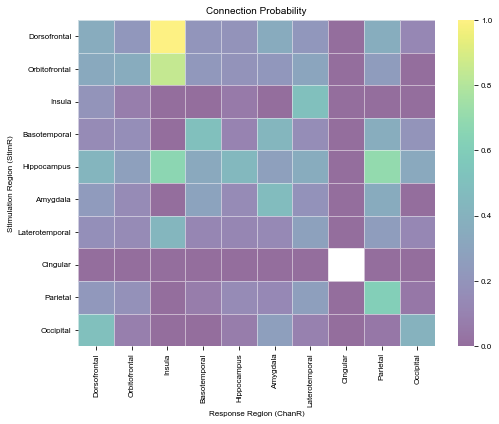

In [115]:
h = 1
data_Con_prob = con_all[['Con_ID', 'StimR', 'ChanR', 'Sig_Con', 'd', 'H']].reset_index(drop=True)
data_Con_prob = data_Con_prob[(data_Con_prob.H==h)&(np.isin(data_Con_prob.StimR, regions_all))&(np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)
# Calculate the ratio of Sig_Con == 1 to the total number of connections for each pair of regions
heatmap_data = data_Con_prob.groupby(['StimR', 'ChanR'])['Sig_Con'].mean().unstack(fill_value=0)
# Create a DataFrame with NaN values for missing labels
missing_labels = list(set(regions_all) - set(heatmap_data.index))
for lab in missing_labels:
    empty_array = pd.DataFrame([[np.max(data_Con_prob.Con_ID)+1, lab, lab, np.nan, np.nan, h]], columns=['Con_ID', 'StimR', 'ChanR', 'Sig_Con', 'd', 'H'])
    data_Con_prob =pd.concat([data_Con_prob,empty_array],0)
data_Con_prob = data_Con_prob.reset_index(drop=True)

heatmap_data = data_Con_prob.groupby(['StimR', 'ChanR'])['Sig_Con'].mean().unstack(fill_value=0)
heatmap_data = heatmap_data.loc[regions_all, regions_all]  # Reorder rows and columns


# Create a DataFrame to store count of Sig_Con == 1 for each pair of regions
count_data = data_Con_prob[data_Con_prob['Sig_Con'] == 1].groupby(['StimR', 'ChanR']).size().unstack(fill_value=0)
# count_data = count_data.loc[regions_all, regions_all]  # Reorder rows and columns

count_data0 = data_Con_prob[data_Con_prob['Sig_Con'] == 0].groupby(['StimR', 'ChanR']).size().unstack(fill_value=0)
#count_data0 = count_data0.loc[regions_all, regions_all]  # Reorder rows and columns

# Calculate the ratio of Sig_Con == 1 to the total number of connections for each pair of regions
ratio_data = data_Con_prob.groupby(['StimR', 'ChanR'])['Sig_Con'].mean().unstack(fill_value=0)
#ratio_data = ratio_data.loc[regions_all, regions_all]  # Reorder rows and columns


# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ratio_data, annot=False, cmap='viridis', alpha=0.57, fmt='.2f', linewidths=0.5, xticklabels=regions_all, yticklabels=regions_all)
plt.title('Connection Probability')
plt.xlabel('Response Region (ChanR)')
plt.ylabel('Stimulation Region (StimR)')

# Annotate the heatmap with count values (percentage and actual ratio)
for i in range(len(regions_all)):
    for j in range(len(regions_all)):
        count = count_data.loc[(count_data.StimR==regions_all[i])&(count_data.StimR==regions_all[i]), #count_data.iloc[i, j]
        count0 = count_data0.iloc[i, j]
        ratio = ratio_data.iloc[i, j]
        plt.text(j + 0.5, i + 0.5, f'{ratio*100:.0f}%\n{count}/{count0+count}', ha='center', va='center', fontsize=7)
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\Connection_probability_interH.svg'
plt.savefig(file)

## Sig connection across

In [135]:
import load_summary as ls
subjs = ["EL010", "EL011", "EL012", "EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]
con_all = ls.get_connections(subjs, sub_path)
con_all = con_all[(con_all.Num_sig_trial >10)].reset_index(drop=True)
# con_all_subj = con_all_subj[(con_all_subj.Sig >0)&(con_all_subj.Num_sig_trial >10)&(con_all_subj.True_peak == 1)].reset_index(drop=True)
con_all_subj['Con_ID'] = con_all_subj.groupby(['Subj', 'Stim', 'Chan']).ngroup()

In [136]:
con_all = ls.get_connections(subjs, sub_path)
con_all.loc[(con_all.Num_sig_trial<=10)| (con_all.True_peak!=1), 'Sig'] = 0

In [137]:
con_all_sig = con_all[(con_all.Sig >0)].reset_index(drop=True)
con_all_sig['Con_ID'] = con_all_sig.groupby(['Subj', 'Stim', 'Chan']).ngroup()

In [11]:
import sklearn

In [138]:
con_all['Sig_test'] ='None'
con_all.loc[(con_all.Zscore>6)&(con_all.Sig>0),'Sig_test'] ='Both' 
con_all.loc[(con_all.Zscore>6)&(con_all.Sig==0),'Sig_test'] ='Z-score' 
con_all.loc[(con_all.Zscore<=6)&(con_all.Sig>0),'Sig_test'] ='Surrogate' 

In [139]:

# Initialize arrays for storing predictions and metrics
metrics = {'Subj': [], 'Kappa': [], 'Jaccard': [], 'Accuracy': []}
p_1_all, p_2_all = np.array([]), np.array([])

for subj in subjs:
    con_summary_all = con_all[con_all.Subj==subj].reset_index(drop=True)
    p_1 = np.array(con_summary_all.Zscore.values > 6) * 1
    p_2 = np.array(con_summary_all.Sig.values > 0) * 1
    # Calculate Cohen's Kappa and Jaccard Index
    kappa = cohen_kappa_score(p_1, p_2)
    jaccard = jaccard_score(p_1, p_2)
    acc = accuracy_score(p_1, p_2)
    # Store kappa and jaccard values
    metrics['Subj'].append(subj)
    metrics['Kappa'].append(kappa)
    metrics['Jaccard'].append(jaccard)
    metrics['Accuracy'].append(acc)

    # Concatenate prediction values
    p_1_all = np.concatenate([p_1_all, p_1]) if p_1_all.size else p_1
    p_2_all = np.concatenate([p_2_all, p_2]) if p_2_all.size else p_2

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'black'},
    'medianprops':{'color':'black'},
    'whiskerprops':{'color':'black'},
    'capprops':{'color':'black'}
}

confusion_matrix = sklearn.metrics.confusion_matrix(p_1_all, p_2_all)


In [173]:
recall = sklearn.metrics.classification_report(p_2_all , p_1_all)
print(recall)

              precision    recall  f1-score   support

           0       0.85      0.96      0.90     38526
           1       0.96      0.86      0.91     45061

    accuracy                           0.91     83587
   macro avg       0.91      0.91      0.91     83587
weighted avg       0.91      0.91      0.91     83587



In [147]:
slope, intercept, r, p, se = scipy.stats.linregress(X, y)

In [140]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Cut 'd' into 20 bins and assign codes
con_all['d_bin'] = pd.cut(con_all['d'], bins=20)
con_all['d_bin_code'] = con_all['d_bin'].cat.codes

grouped = con_all.groupby(['d_bin_code', 'Sig_test']).size().unstack(fill_value=0)
proportions = grouped.div(grouped.sum(axis=1), axis=0)

# Reset the index to make 'd_bin' a column again for easier readability
proportions.reset_index(inplace=True)


# Setup the linear regression model
X = proportions['d_bin_code'].values
y = proportions['Both'].values

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Print the summary of the regression
print(model.summary())


                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.123
Model:                            OLS   Adj. R-squared (uncentered):              0.077
Method:                 Least Squares   F-statistic:                              2.658
Date:                Tue, 19 Mar 2024   Prob (F-statistic):                       0.119
Time:                        17:43:00   Log-Likelihood:                         -13.377
No. Observations:                  20   AIC:                                      28.75
Df Residuals:                      19   BIC:                                      29.75
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [164]:
print(np.percentile(metrics['Kappa'], 25))
print(np.percentile(metrics['Kappa'], 50))
print(np.percentile(metrics['Kappa'], 75))

0.7859800297929042
0.8208565062728002
0.8681785797026396


In [167]:
np.median(metrics['Accuracy'])

0.9204069419509275

In [165]:
print(np.percentile(metrics['Accuracy'], 25))
print(np.percentile(metrics['Accuracy'], 50))
print(np.percentile(metrics['Accuracy'], 75))

0.8994381305069595
0.9204069419509275
0.9457870526671912


-0.05282148154880215 0.8933476552552779 0.918615145489295 3.017834267262647e-11 0.0037057773338901316
-0.011150066026987863 0.6807840327316423 0.1323435122632405 0.1049909490135779 0.006549727321546162


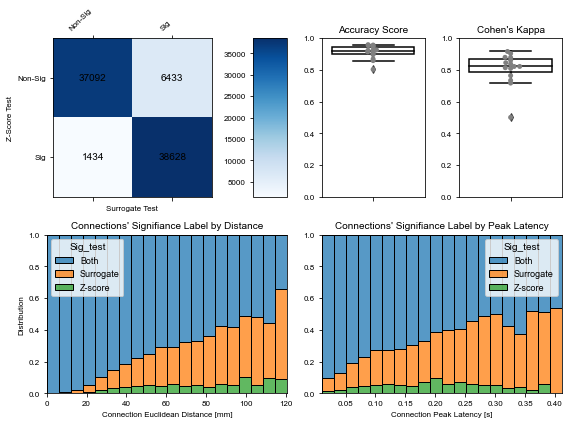

In [152]:
fig, axes = plt.subplots(2, 4, figsize=(8, 6), gridspec_kw={'width_ratios': [2.5, 0.5, 1.5, 1.5]})

# Plotting the confusion matrix
im = axes[0,0].matshow(confusion_matrix, cmap=plt.cm.Blues)
# Adding labels and titles for the confusion matrix subplot
for (i, j), val in np.ndenumerate(confusion_matrix):
    axes[0,0].text(j, i, f'{int(val)}', ha='center', va='center', color='black')
axes[0,0].set_xlabel('Surrogate Test')
axes[0,0].set_ylabel('Z-Score Test')
# axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xticks(np.arange(confusion_matrix.shape[1]))
axes[0,0].set_yticks(np.arange(confusion_matrix.shape[0]))
axes[0,0].set_xticklabels(['Non-Sig', 'Sig'], rotation=45, ha="right")
axes[0,0].set_yticklabels(['Non-Sig', 'Sig'])

# Adjust for the colorbar
#cax = fig.add_axes([0.365, 0.55, 0.02, 0.35])  # x, y, width, height
#plt.colorbar(im, cax=axes[0,1])

cax = axes[0,1]#.inset_axes([0, 0, 0.2, 1])  # Adjust the position and width as needed

# Add a colorbar to the second subplot
plt.colorbar(im, cax=cax)
cax.yaxis.set_ticks_position('left')

# Accuracy and Cohen's Kappa plots
ax_acc = axes[0,2]
sns.boxplot(y='Accuracy', data=metrics, ax=ax_acc, **PROPS)
sns.swarmplot(y='Accuracy', data=metrics, ax=ax_acc, color="grey", edgecolor="black", dodge=True)
ax_acc.set_title('Accuracy Score')
ax_acc.set_ylim([0, 1])

ax_kappa = axes[0,3]
sns.boxplot(y='Kappa', data=metrics, ax=ax_kappa, **PROPS)
sns.swarmplot(y='Kappa', data=metrics, ax=ax_kappa, color="grey", edgecolor="black", dodge=True)
ax_kappa.set_title("Cohen's Kappa")
ax_kappa.set_ylim([0, 1])

# Histograms for `d` and `peak_latency`
ax_d = plt.subplot2grid((2, 4), (1, 0), colspan=2, fig=fig)
sns.histplot(x='d', hue='Sig_test', data=con_all[~con_all['Sig_test'].isin(['None'])], ax=ax_d, multiple='fill', bins=20)
ax_d.set_title("Connections' Signifiance Label by Distance")
ax_d.set_ylabel('Distribution')
ax_d.set_xlabel('Connection Euclidean Distance [mm]')
# add linear regression results
# Cut 'd' into 20 bins and assign codes
con_all['d_bin'] = pd.cut(con_all['d'], bins=20)
con_all['d_bin_code'] = con_all['d_bin'].cat.codes

grouped = con_all.groupby(['d_bin_code', 'Sig_test']).size().unstack(fill_value=0)
proportions = grouped.div(grouped.sum(axis=1), axis=0)

# Reset the index to make 'd_bin' a column again for easier readability
proportions.reset_index(inplace=True)


# Setup the linear regression model
X = proportions['d_bin_code'].values
y = proportions['Both'].values

slope, intercept, r, p, se = scipy.stats.linregress(X, y)
print(slope, intercept, r**2, p, se)

ax_pd = plt.subplot2grid((2, 4), (1, 2), colspan=2, fig=fig)
sns.histplot(x='peak_latency', hue='Sig_test', data=con_all[~con_all['Sig_test'].isin(['None'])], ax=ax_pd, multiple='fill', bins=20)
ax_pd.set_title("Connections' Signifiance Label by Peak Latency")
ax_pd.set_ylabel('')
ax_pd.set_xlabel('Connection Peak Latency [s]')
# Cut 'peak_latency' into 20 bins and assign codes
con_all['d_bin'] = pd.cut(con_all['peak_latency'], bins=20)
con_all['d_bin_code'] = con_all['d_bin'].cat.codes

grouped = con_all.groupby(['d_bin_code', 'Sig_test']).size().unstack(fill_value=0)
proportions = grouped.div(grouped.sum(axis=1), axis=0)

# Reset the index to make 'd_bin' a column again for easier readability
proportions.reset_index(inplace=True)


# Setup the linear regression model
X = proportions['d_bin_code'].values
y = proportions['Both'].values
# todo: show results
slope, intercept, r, p, se = scipy.stats.linregress(X, y)
print(slope, intercept, r**2, p, se)
plt.tight_layout()
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\CCEP_sigCon_quantification.svg')
# Show the plot
plt.show()

## SNR

In [35]:
start = 1
for subj in subjs:
    path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
    snr_file  = path_patient_analysis + '\\' + folder + '\\' + cond_folder + '\\data\\SNR_all.csv'  # summary_general
    table = pd.read_csv(snr_file)
    table.insert(0, 'Subj', subj)
    if start:
        table_all = table
        start = 0
    else:
        table_all = pd.concat([table_all, table])
        


In [36]:
table_all['Label'] = 'Surr'
table_all.loc[(table_all.Real == 1)&(table_all.Sig==1), 'Label'] = 'Sig'
table_all.loc[(table_all.Real == 1)&(table_all.Sig==0), 'Label'] = 'Non-Sig'


-0.1003578897151346 -1.1882301644699655 1.624292811972247
1.3384378919565572 -0.4931151566502401 6.1245580251920275
10.041184935890945 4.661311594219903 36.517537526536664


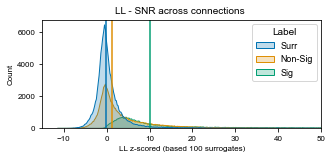

-0.1003578897151346 -1.1882301644699655 1.624292811972247
1.3384378919565572 -0.4931151566502401 6.1245580251920275
10.041184935890945 4.661311594219903 36.517537526536664


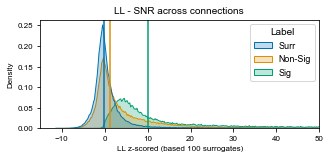

In [43]:
metric = 'LL'
hue_order =  ['Surr', 'Non-Sig', 'Sig']
colors = sns.color_palette('colorblind', n_colors=len(hue_order))  # Define a color for each hue value
for stat in ['count', 'density']:
    plt.figure(figsize=(5,2))
    sns.histplot(table_all, x=metric+"_SNR", hue="Label", stat=stat, hue_order = hue_order,kde=False, element="poly", common_norm=False, palette = colors)
    for ix, hue in enumerate(hue_order):
        plt.axvline(np.median(table_all.loc[table_all.Label == hue, metric+"_SNR"]), color=colors[ix])
        md = np.median(table_all.loc[table_all.Label == hue, metric+"_SNR"])
        IQR1 = np.quantile(table_all.loc[table_all.Label == hue, metric+"_SNR"],0.25)
        IQR2 = np.quantile(table_all.loc[table_all.Label == hue, metric+"_SNR"],0.75)
        print(md, IQR1, IQR2)
    plt.xlim([-15, 50])
    plt.title(metric+' - SNR across connections ')
    plt.xlabel(metric + ' z-scored (based 100 surrogates)')
    plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\SNR_Mean_hist_'+stat+'.svg')
    plt.show()

In [ ]:
metric = 'LL'
hue_order =  ['Surr', 'Non-Sig', 'Sig']
colors = sns.color_palette('colorblind', n_colors=len(hue_order))  # Define a color for each hue value
plt.figure(figsize=(5,2))
sns.histplot(table_all, x=metric+"_SNR", hue="Label", hue_order = hue_order,kde=False, element="poly", common_norm=False, palette = colors)
for ix, hue in enumerate(hue_order):
    plt.axvline(np.median(table_all.loc[table_all.Label == hue, metric+"_SNR"]), color=colors[ix])
plt.xlim([-15, 50])
plt.title(metric+' - SNR across connections ')
plt.xlabel(metric + ' z-scored (based 100 surrogates)')
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\SNR_Mean_hist.svg')

In [ ]:
metric = 'LL'
hue_order =  ['Surr', 'Non-Sig', 'Sig']
sns.histplot(table_all, x=metric+"_SNR", hue="Label", hue_order = hue_order,kde=False, element="step", palette = colors)
for ix, hue in enumerate(hue_order):
    plt.axvline(np.median(table_all.loc[table_all.Label == hue, metric+"_SNR"]), color=colors[ix])
plt.xlim([-15, 50])
plt.title(metric+' - SNR across connections ')
plt.xlabel(metric + ' z-scored (based 100 surrogates)')

In [14]:
con_trial = bf.add_sleepstate(con_trial)

In [ ]:
p_val = 0.95

In [ ]:
ss = 'Wake'
sc = 8
rc = 60
ylim = 300
sig_trials = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.p_value_LL>p_val)&(con_trial.Artefact<1)&(con_trial.SleepState==ss), 'Num'].values
nonsig_trials = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.p_value_LL<p_val)&(con_trial.Artefact<1)&(con_trial.SleepState==ss), 'Num'].values


In [ ]:
ss = 'Wake'
sc = 0
rc = 2
ylim = 600
sig_trials = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.p_value_LL>p_val)&(con_trial.Artefact<1), 'Num'].values
nonsig_trials = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.p_value_LL<p_val)&(con_trial.Artefact<1), 'Num'].values


metric = 'p2p'# Creating subplots
fig, axs = plt.subplots(1, 2, figsize=(5,2))
plt.suptitle(ss+ ': '+labels_all[sc]+' -- '+labels_all[rc])
# Plot significant trials
for i in range(len(sig_trials)):
    axs[0].plot(x_ax, EEG_resp[rc, sig_trials[i]],linewidth = 0.5, alpha=0.1)
axs[0].plot(x_ax, ff.lp_filter(np.mean(EEG_resp[rc, sig_trials], axis=0), 30, Fs), linewidth=2, label='sig', color='k')
axs[0].set_xlim([-0.6, 1])
axs[0].axvline(0, color=[0, 0, 0])
axs[0].set_title('Significant Trials N='+str(len(sig_trials)))
axs[0].set_ylim([-ylim, ylim])

# Plot non-significant trials
for i in range(len(nonsig_trials)):
    axs[1].plot(x_ax, EEG_resp[rc, nonsig_trials[i]],linewidth = 0.5, alpha=0.1)
axs[1].plot(x_ax, ff.lp_filter(np.mean(EEG_resp[rc, nonsig_trials], axis=0), 30, Fs), linewidth=2, label='non-sig', color='k')
axs[1].set_xlim([-0.6, 1])
axs[1].axvline(0, color=[0, 0, 0])
axs[1].set_title('Non-Significant Trials N='+str(len(nonsig_trials)))
axs[1].set_ylim([-ylim, ylim])

plt.tight_layout()
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\SNR\Example\\'+subj+'_'+labels_all[sc]+'_'+labels_all[rc]+'.svg')
plt.show()

In [ ]:

metric = 'p2p'# Creating subplots
fig, axs = plt.subplots(1, 2, figsize=(5,2))
plt.suptitle(ss+ ': '+labels_all[sc]+' -- '+labels_all[rc])
# Plot significant trials
for i in range(len(sig_trials)):
    axs[0].plot(x_ax, EEG_resp[rc, sig_trials[i]], alpha=0.1)
axs[0].plot(x_ax, ff.lp_filter(np.mean(EEG_resp[rc, sig_trials], axis=0), 30, Fs), linewidth=3, label='sig', color='k')
axs[0].set_xlim([-0.6, 1])
axs[0].axvline(0, color=[0, 0, 0])
axs[0].set_title('Significant Trials')
axs[0].set_ylim([-ylim, ylim])

# Plot non-significant trials
for i in range(len(nonsig_trials)):
    axs[1].plot(x_ax, EEG_resp[rc, nonsig_trials[i]], alpha=0.1)
axs[1].plot(x_ax, ff.lp_filter(np.mean(EEG_resp[rc, nonsig_trials], axis=0), 30, Fs), linewidth=3, label='non-sig', color='k')
axs[1].set_xlim([-0.6, 1])
axs[1].axvline(0, color=[0, 0, 0])
axs[1].set_title('Non-Significant Trials')
axs[1].set_ylim([-ylim, ylim])

plt.tight_layout()
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\SNR\Example\\'+subj+'_'+labels_all[sc]+'_'+labels_all[rc]+'.svg')
plt.show()

In [ ]:
tab_all

In [ ]:
sc = 18
rc = 65
p_val = 0.9
sig_trials = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.p_value>p_val)&(con_trial.Artefact<1), 'Num'].values

for i in range(len(sig_trials)):
    plt.plot(x_ax, EEG_resp[rc, sig_trials[i]], alpha = 0.1)
plt.plot(x_ax, np.mean(EEG_resp[rc, sig_trials],0), linewidth = 3, label = 'sig', color = 'k')
plt.xlim([-0.6, 1])
plt.axvline(0, color=[0,0,0])
plt.title('sig')
plt.ylim([-ylim, ylim])
plt.show()
nonsig_trials = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.p_value<p_val)&(con_trial.Artefact<1), 'Num'].values
for i in range(len(nonsig_trials)):
    plt.plot(x_ax, EEG_resp[rc, nonsig_trials[i]], alpha = 0.1)
plt.plot(x_ax, np.mean(EEG_resp[rc, nonsig_trials],0), linewidth = 3, label = 'non-sig', color = 'k')
plt.xlim([-0.6, 1])
plt.axvline(0, color=[0,0,0])
plt.title('non-sig')
plt.ylim([-ylim, ylim])
plt.show()

In [ ]:
con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.p_value<0.95)&(con_trial.Artefact<1)]

In [ ]:
sig_trials

## Q-Q Plot

In [ ]:
con_trial = bf.add_sleepstate(con_trial)

In [27]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
# Example data - replace with your actual data
# Assuming con_trial is a DataFrame with your data
# ...
def check_norm_dist(data, ax):
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=ax)
    # Perform the tests
    if len(data)>8:
        shapiro_test = stats.shapiro(data)
        dagostino_test = stats.normaltest(data)
        ax.set_title(f"Q-Q Plot for LL during {ss}\nShapiro p={shapiro_test[1]:.2g}, D’Agostino p={dagostino_test[1]:.2g}")
    else:
        shapiro_test = np.nan
        dagostino_test = np.nan
    
        # Setting the title to include p-values
        ax.set_title(f"Q-Q Plot for LL during {ss}\nShapiro p= nan, D’Agostino p= nan")


In [14]:
p_val = 0.95

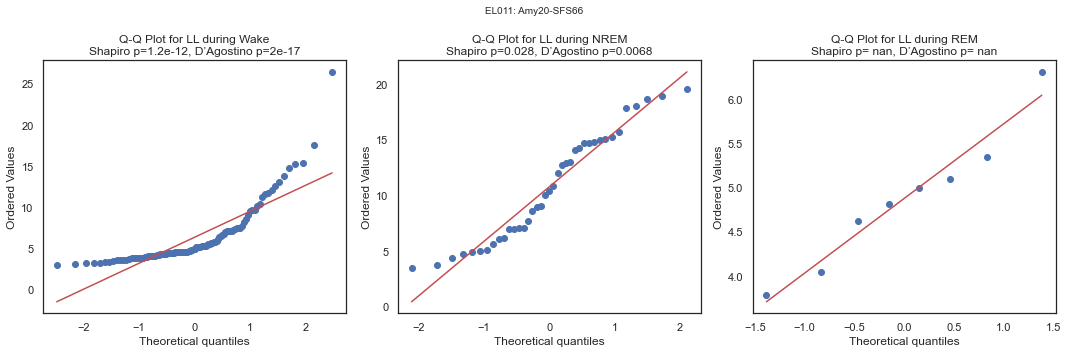

In [44]:
sc = 19
rc = 65
# Creating a 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle(subj +': '+labels_all[sc]+'-'+labels_all[rc])
# Loop through the sleep states
sleep_states = ['Wake', 'NREM', 'REM']
for i, ss in enumerate(sleep_states):
    LL = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.Sig==1)&(con_trial.Artefact<1)&(con_trial.SleepState==ss), 'LL'].values
    check_norm_dist(LL, axes[i])
plt.tight_layout()
plt.show()

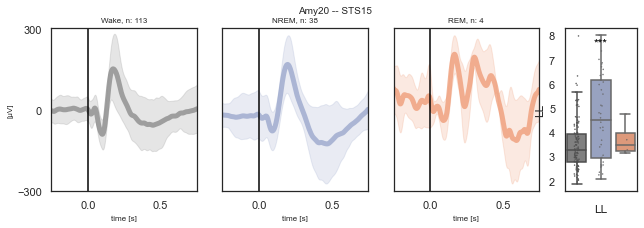

In [43]:
fig_sleep.plot_SleepState(sc, rc, EEG_resp, con_trial[con_trial.Sig==1], labels_all, metrics= ['LL'])
plt.show()

In [ ]:
s = np.random.normal(5, 0.3, 1000)
check_norm_dist(s)

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
# Example data
data = np.random.normal(loc=0, scale=1, size=100)  # Replace with your array
def check_norm_dist(data):
    # Shapiro-Wilk Test
    shapiro_test = stats.shapiro(data)
    print(f"Shapiro-Wilk Test: Statistic={shapiro_test[0]}, p-value={shapiro_test[1]}")
    # D’Agostino’s K-squared Test
    dagostino_test = stats.normaltest(data)
    print(f"D’Agostino’s K-squared Test: Statistic={dagostino_test[0]}, p-value={dagostino_test[1]}")
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=plt)
    plt.title("Normal Q-Q Plot")
    plt.show()
    

In [ ]:
sc = 0
rc = 2
for ss in ['Wake', 'NREM', 'REM']:
    LL = con_trial.loc[(con_trial.Stim==sc)&(con_trial.Chan==rc)&(con_trial.p_value_LL>p_val)&(con_trial.Artefact<1)&(con_trial.SleepState==ss), 'LL'].values

In [ ]:
check_norm_dist(LL)

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
# Example data
data = np.random.normal(loc=0, scale=1, size=100)  # Replace with your array
def check_norm_dist(data):
    # Shapiro-Wilk Test
    shapiro_test = stats.shapiro(data)
    print(f"Shapiro-Wilk Test: Statistic={shapiro_test[0]}, p-value={shapiro_test[1]}")
    # D’Agostino’s K-squared Test
    dagostino_test = stats.normaltest(data)
    print(f"D’Agostino’s K-squared Test: Statistic={dagostino_test[0]}, p-value={dagostino_test[1]}")
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=plt)
    plt.title("Normal Q-Q Plot")
    plt.show()

## Onset

In [13]:
def plot_CCEP_onset(EEG_resp, con_trial, labels_all, sc_all, rc_all, CC_summ, w_LL = 0.25, Fs = 500, t0 = 1):
    xlim = [-0.25, 0.5]
    ylim_CCEP = [-350, 350]
    ylim_LL = [0, 8]
    fig, axes = plt.subplots(3, len(sc_all), figsize=(len(sc_all)*2.5, 6))  # Create a 1x3 subplot grid
    fig.patch.set_facecolor('xkcd:white')

    for ix, sc, rc in zip(np.arange(len(sc_all)), sc_all, rc_all):
        lists = con_trial[(con_trial['Chan'] == rc) & (con_trial['Stim'] == sc)& (con_trial['Sig'] == 1)& (con_trial['Artefact'] <1)].reset_index(drop=True)
        stimnum = lists['Num'].values.astype('int')
        data_CCEP = ff.lp_filter(np.mean(EEG_resp[rc, stimnum, :], 0), 30, Fs)
        WOI = CC_summ.loc[(CC_summ.Stim == sc) & (CC_summ.Chan == rc), 't_WOI'].values[0]
        delay, data_LL, d1_LL, d2_LL = CCEP_func.cal_delay(data_CCEP, WOI=WOI)
        #data_CCEP = ff.lp_filter(data_CCEP, 30, Fs)
        pk_CCEP_loc = np.argmax(abs(data_CCEP[int(t0 * Fs):int((t0+WOI+0.125) * Fs)]))
        pk_CCEP = data_CCEP[int(t0*Fs+pk_CCEP_loc)]
        # plot second derivative of LL
        ax = axes[2, ix]
        ax.plot(x_ax + w_LL / 2, d2_LL, linewidth=2, alpha=0.5)
        d2_LL[d1_LL < 0] = np.nan  # only increase intresting
        d2_LL[:int((t0 - w_LL / 2) * Fs)] = np.nan  # not before Stim
        d2_LL[int((t0 * Fs) + pk_CCEP_loc):] = np.nan  # not before Stim
        ax.plot(x_ax + w_LL / 2, d2_LL, linewidth=2)
        pk_loc = np.nanargmax(d2_LL[t0 * Fs:]) / Fs
        pk = np.nanmax(d2_LL[t0 * Fs:])
        ax.plot(pk_loc + w_LL / 2, pk, 'o', color=[0, 1, 0])
        ax.set_xlabel('time [s]')
        ax.set_xticks([0, 0.5])
        if ix == 0:
            ax.set_ylabel('[uV/ms]')
            # ax.set_yticks([0, 3, 6])
        else:
            ax.set_yticks([])
        ax.axvline(0, color=[0, 0, 0])
        ax.set_xlim(xlim)
        ax.set_ylim([-0.03, 0.03])
        ax.set_box_aspect(1.5 / 2)
        # Plot LL
        ax = axes[1, ix]
        ax.plot(x_ax+w_LL/2, data_LL, linewidth=2)
        #ax.set_xlabel('time [s]')
        #ax.set_xticks([0, 0.5])
        if ix ==0:
            ax.set_ylabel('[uV/ms]')
            ax.set_yticks([0, 3, 6])
        else:
            ax.set_yticks([])
        ax.axvline(0, color=[0, 0, 0])
        ax.set_xlim(xlim)
        ax.set_ylim(ylim_LL)
        ax.axvline(pk_loc + w_LL / 2, color=[0, 1, 0])
        ax.set_box_aspect(1.5 / 2)
        # plot orignal data with a shadowd window based on peak LL
        ax = axes[0, ix]
        ax.plot(x_ax, data_CCEP, linewidth=2)
        ax.axvspan(WOI, WOI+0.25, color = [0,0,0], alpha =0.1)
        ax.set_title(labels_all[sc] + ' - ' + labels_all[rc])
        if ix ==0:
            ax.set_ylabel('[uV]')
            ax.set_yticks([-400,0,400])
        else:
            ax.set_yticks([])
        ax.axvline(0, color=[0, 0, 0])
        ax.set_xlim(xlim)
        ax.set_ylim(ylim_CCEP)
        ax.set_xticks([])
        ax.set_box_aspect(1.5 / 2)
        # ax.axvline(pk_loc, color=[0, 1,0])
        ax.axvline(delay, color=[0, 1, 0])
        ax.plot(pk_CCEP_loc/Fs, pk_CCEP, 'o', color=[1, 0, 0])


    return fig, axes

(<Figure size 900x432 with 15 Axes>,
 array([[<AxesSubplot:title={'center':'MTG37 - STS15'}, ylabel='[uV]'>,
         <AxesSubplot:title={'center':'HIPP7 - SIG56'}>,
         <AxesSubplot:title={'center':'Amy20 - ITS46'}>,
         <AxesSubplot:title={'center':'Tpole4 - MTG38'}>,
         <AxesSubplot:title={'center':'Amy19 - STS15'}>],
        [<AxesSubplot:ylabel='[uV/ms]'>, <AxesSubplot:>, <AxesSubplot:>,
         <AxesSubplot:>, <AxesSubplot:>],
        [<AxesSubplot:xlabel='time [s]', ylabel='[uV/ms]'>,
         <AxesSubplot:xlabel='time [s]'>, <AxesSubplot:xlabel='time [s]'>,
         <AxesSubplot:xlabel='time [s]'>, <AxesSubplot:xlabel='time [s]'>]],
       dtype=object))

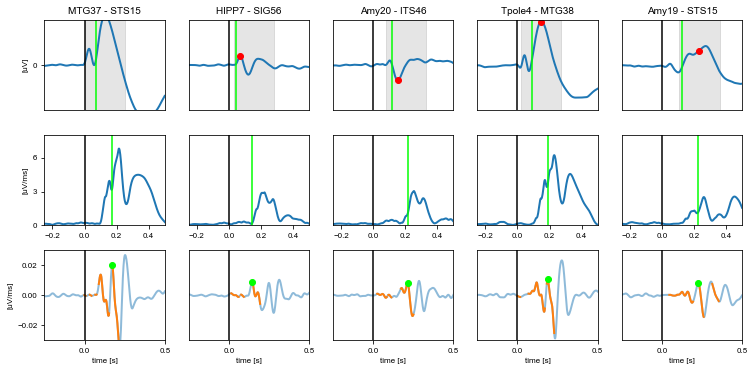

In [14]:
CCEP_supp.plot_CCEP_onset(EEG_resp, con_trial, labels_all, sc_all, rc_all, CC_summ, w_LL = 0.25, Fs = 500, t0 = 1)

In [ ]:
fig, axes = plt.subplots(1, 4,figsize=(8,3), gridspec_kw={'width_ratios': [4, 0.5, 1.5, 1.5]})

In [ ]:
stop

In [ ]:

example_surr = np.zeros((4, 2))
example_surr[0] = [3, 74]
example_surr[1] = [4, 64] #64
example_surr[2] = [65, 15] #64, [50, 75]
example_surr[3] = [49, 56] #64
example_surr = example_surr.astype('int')

example_z = np.zeros((4, 2))
example_z[0] = [53, 0]
example_z[1] = [53, 76] #64
example_z[2] = [57, 20] #64[54, 68]
example_z[3] = [55, 49] #64
example_z = example_z.astype('int')
# Call the function with your data
fig, axes = CCEP_plot.plot_SigCon_examples(example_z[:,0], example_z[:,1], con_trial, EEG_resp,labels_all, 0)
# plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\CCEP_sigCon_example_zscore.svg')

## LL against distance and delay

In [ ]:
cond_folder ='CR'
folder = 'Brainmapping'

In [ ]:
from scipy import stats

In [17]:
subjs = ["EL010", "EL011","EL012","EL013", "EL014", "EL015", "EL016", "EL017", "EL019", "EL020", "EL021",
         "EL022", "EL025", "EL026", "EL027", "EL028"]

# subjs = ["EL011","EL012","EL013", "EL014", "EL015", "EL016", "EL017", "EL019"]
start = 1
for subj in subjs:
    for ss in ['Wake', 'NREM', 'REM']:
        path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
        summary_gen_path = path_patient_analysis + '\\' + folder + '\\' + cond_folder + '\\data\\summ_' + ss + '.csv'  # summary_general
            
        con_summary_all = pd.read_csv(summary_gen_path)
        con_summary_all = con_summary_all.drop_duplicates()
        con_summary_all['Subj'] = subj
        if start:
            con_all = con_summary_all
            start = 0
        else:
            con_all = pd.concat([con_all, con_summary_all]).reset_index(drop=True)        

In [20]:
df = con_all[np.isin(con_all.StimR, regions_all)&(abs(con_all.DI)>0.1)&(con_all.d>20)].reset_index(drop=True)
df = df[['Subj', 'SleepState', 'd', 'DI', 'StimR', 'ChanR']]
    

In [ ]:
from statsmodels.formula.api import ols 
  
# Performing two-way ANOVA 
model = ols('DI ~ C(StimR):C(ChanR)+C(StimR):C(ChanR):C(SleepState) + C(SleepState)+ C(StimR)+ C(ChanR)', data=df).fit() 
sm.stats.anova_lm(model, typ=2) 

In [ ]:
# Define the colors for the custom colormap (dark green, white, gray)
colors = [(0.14117647, 0.52941176, 0.12941176), (1,1,1), (0.2, 0.2, 0.2)]  # R, G, B

# Create the colormap
n_bins = 100  # Increase this number for smoother transitions
cmap_name = 'GreenWhiteGray'
cmap_DI = matplotlib.colors.LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)


In [ ]:
for ss in ['Wake', 'NREM', 'REM']:
    df = con_all[np.isin(con_all.StimR, regions_all)&(abs(con_all.DI)<1)&(abs(con_all.DI)>0.1)&(con_all.d>20)&(con_all.SleepState ==ss)].reset_index(drop=True)
    df = df[['Subj', 'SleepState', 'd', 'DI', 'StimR', 'ChanR']]
    metric = 'DI'

    # df = con_all[(con_all.SleepState=='Wake')&(con_all.Sig>0)&np.isin(con_all.StimR, regions_all)&np.isin(con_all.ChanR, regions_all)].reset_index(drop=True)
    metric = 'DI'
    cal = 'median'
    grouped_data = df.groupby(['StimR', 'ChanR'])[metric].agg([cal, 'std'])
    # 2. Create a Data Matrix
    data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
    for (stim, chan), values in grouped_data.iterrows():
        if stim in regions_all and chan in regions_all:
            data_matrix.at[stim, chan] = f"{values[cal]:.2f}\n±{values['std']:.2f}"

    # Reorder data matrix and annotation matrix
    reordered_data = grouped_data[cal].unstack().reindex(index=regions_all, columns=regions_all)
    annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

    # 3. Plot the Heatmap with ordered x-ticks and colorbar limit
    plt.figure(figsize=(8, 5))
    ax = sns.heatmap(reordered_data, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap=cmap_DI, cbar=True, vmin = -0.5, vmax=0.5)

    # Ensuring the heatmap is square
    ax.set_aspect('equal', 'box')
    # 4. Add titles and labels
    plt.title(ss+': '+cal+' and Standard Deviation of Delays between Brain Regions')
    plt.xlabel('Response Region')
    plt.ylabel('Stimulation Region')
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\'+ss+'_'+metric+'_region.svg'
    plt.savefig(file)
    file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\'+ss+'_'+metric+'_region.jpg'
    plt.savefig(file, dpi = 300)
    
plt.show()


In [ ]:
sns.catplot(x='ChanR', y= 'DI', hue='SleepState',row = 'StimR',  data = con_all[np.isin(con_all.StimR, regions_all)&(con_all.d>20)&(con_all.DI>-1)], aspect = 2, palette= color_sleep, kind = 'box', order = regions_all)

In [ ]:
np.percentile(filtered_df['Mean_P2P'], 20)

In [21]:
# Filter DataFrame for relevant SleepStates
filtered_df = con_all[con_all['SleepState'].isin(['Wake', 'NREM', 'REM'])]

filtered_df = filtered_df[filtered_df.Num_sig_trial>20].reset_index(drop=True)

filtered_df = filtered_df[filtered_df.Mean_LL>1.3].reset_index(drop=True)
filtered_df = filtered_df[filtered_df.Mean_P2P>153].reset_index(drop=True)

# First, calculate the mean delay for each group
grouped = filtered_df.groupby(['Subj', 'Stim', 'Chan', 'SleepState'])['delay'].mean()

# Unstack the SleepState level, which pivots SleepState into columns
unstacked = grouped.unstack(level='SleepState')

# Optionally, rename the columns for clarity
unstacked.columns = [f'delay_{state}' for state in unstacked.columns]

# Reset the index to flatten the DataFrame
final_df = unstacked.reset_index()

final_df['diff'] = abs(final_df['delay_NREM']-final_df['delay_Wake'])
# final_df.loc[(final_df['diff'] >0.05)&(final_df.Subj =='EL011')]

NameError: name 'stats' is not defined

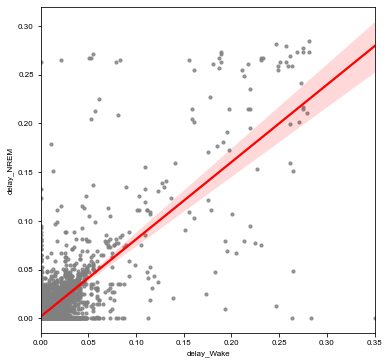

In [22]:
plt.figure(figsize=(6,6))
final_df = final_df[~np.isnan(final_df.delay_Wake)&~np.isnan(final_df.delay_NREM)].reset_index(drop=True)
# Scatter plot with linear regression line
sns.regplot(x='delay_Wake', y='delay_NREM', data=final_df, line_kws=dict(color="r"), scatter_kws={'s': 10, 'color':'gray'})

# Calculate the linear regression parameters and R^2
slope, intercept, r_value, p_value, std_err = stats.linregress(final_df['delay_Wake'], final_df['delay_NREM'])

# Add R^2 to the plot
plt.text(0.05, 0.95, f'R² = {r_value**2:.2f}', transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top')

plt.plot([0,1], [0,1], color=[0,0,0], ls= '--')
plt.xlim([-0.005,0.2])
plt.ylim([-0.005,0.2])

In [24]:
con_trial = bf.add_sleepstate(con_trial)

In [ ]:
k = -1

In [ ]:
final_df.loc[(final_df['diff'] >0.05)&(final_df.Subj =='EL011')]

0.020999999999999998
0.029000000000000005
0.031000000000000007


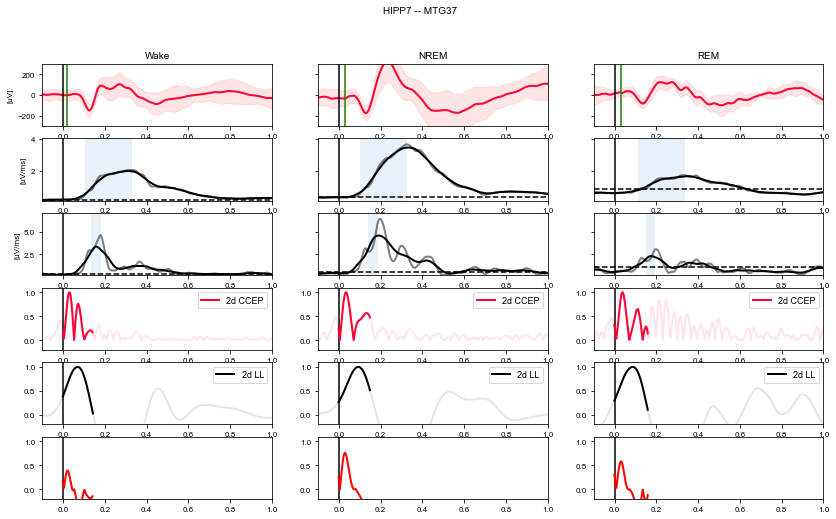

In [55]:
sc = 6
rc = 36
plot_CCEP_onset(EEG_resp, con_trial, labels_all, sc, rc, final_df, Fs = 500, t0 = 1)
plt.show()

In [32]:
ss ='NREM'
lists = con_trial[(con_trial['Chan'] == rc) & (con_trial['Stim'] == sc)& (con_trial['Sig'] == 1)& (con_trial['Artefact'] <1)& (con_trial['SleepState']==ss)].reset_index(drop=True)
stimnum = lists['Num'].values.astype('int')
data_CCEP = np.mean(EEG_resp[rc, stimnum, :], 0)
np.savetxt("CCEP_test_"+ss+".csv", data_CCEP, delimiter=",")


In [111]:
len(lists)

3

In [16]:
from scipy.signal import find_peaks

0.03200000000000003

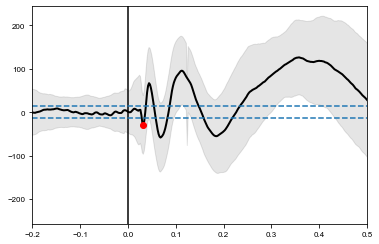

In [60]:
sc = 6
rc = 2
ss = 'Wake'
peak_latency(EEG_resp, con_trial, ss, sc, rc, WOI = 0, w_LL= 0.25, Fs=500, t0=1)

In [59]:
def peak_latency(EEG_resp, con_trial, ss, sc, rc, WOI = 0, w_LL= 0.25, Fs=500, t0=1):
    lists = con_trial[(con_trial['Chan'] == rc) & (con_trial['Stim'] == sc) & (con_trial['Sig'] == 1) & (con_trial['Artefact'] < 1) & (con_trial['SleepState'] == ss)].reset_index(drop=True)
    stimnum = lists['Num'].values.astype('int')
    trials = EEG_resp[rc, stimnum, :]
    BL_period = [int((t0-0.2)*Fs), int((t0-0.00)*Fs)]
    # 1. Remove median based on baseline period from each trial 
    bl_median = np.median(trials[:, BL_period[0]:BL_period[1]], axis=1)
    trials = trials - bl_median[:, None]
    
    # 2. Average signal
    mean_signal = np.mean(trials, axis=0)
    # mean_signal_plot = np.mean(trials, axis=0)
    std_signal_plot = np.std(trials, axis=0)
    
    # 3. Subtract BL median
    mean_signal = mean_signal - np.median(mean_signal[BL_period[0]:BL_period[1]])
    
    # 4. Calculate standard deviation of baseline period
    std = np.std(mean_signal[BL_period[0]:BL_period[1]])
    
    # Plot figure
    fig, ax = plt.subplots()
    x_ax = np.arange(mean_signal.size) / Fs - t0
    ax.plot(x_ax, mean_signal, linewidth=2, color=[0, 0, 0])
    
    # 5. Threshold: +/- 3.4 std, find first peak crossing this threshold
    get_peak = 1
    factor = 3.5
    mean_signal[:int((t0-0.005)*Fs)] = 0
    mean_signal[int((t0+WOI+w_LL/2)*Fs)] = 0
    while get_peak:
        factor = factor-0.1
        threshold = factor * std
        peaks, _ = find_peaks(mean_signal, height=threshold)
        neg_peaks, _ = find_peaks(-mean_signal, height=threshold)
        # Finding the first peak
        first_peak = None
        if peaks.size > 0 or neg_peaks.size > 0:
            all_peaks = np.sort(np.concatenate((peaks, neg_peaks)))
            first_peak = all_peaks[0]
            get_peak = 0

    ax.fill_between(x_ax, mean_signal - std_signal_plot, mean_signal + std_signal_plot, alpha=0.1, color=[0, 0, 0])
    ax.axvline(0, color=[0, 0, 0])
    ax.axhline(-threshold, linestyle='--')
    ax.axhline(threshold, linestyle='--')

    # Highlight the first peak
    if first_peak is not None:
        ax.plot(x_ax[first_peak], mean_signal[first_peak], 'ro')

    ax.set_xlim([-0.2, 0.5])

    return first_peak / Fs - t0 if first_peak is not None else None

0.008000000000000007 -0.007000000000000006


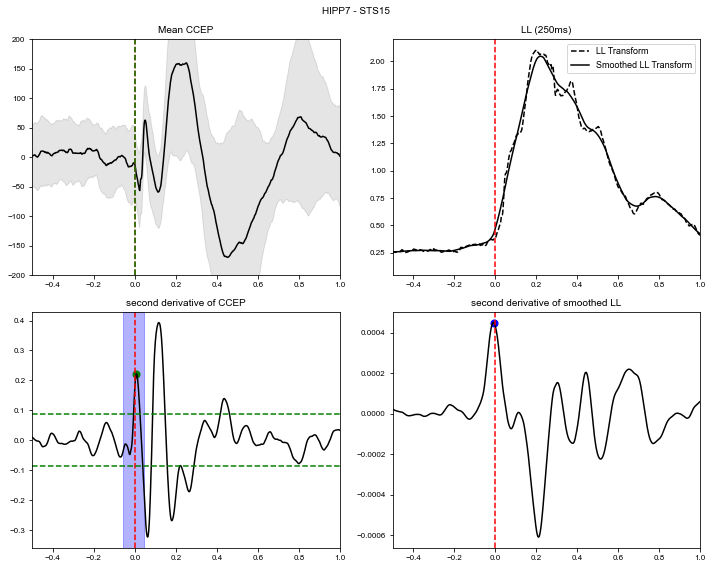

In [292]:
sc = 6
rc = 14
ss = 'Wake'
lists = con_trial[(con_trial['Chan'] == rc) & (con_trial['Stim'] == sc)& (con_trial['Sig'] == 1)& (con_trial['Artefact'] <1)& (con_trial['SleepState']==ss)].reset_index(drop=True)
if len(lists)>10:
    stimnum = lists['Num'].values.astype('int')
    signal_CCEP = np.mean(EEG_resp[rc, stimnum, :], 0)
    std = np.std(EEG_resp[rc, stimnum, :], 0)
    fig = plot_signals(signal_CCEP, std, Fs=500, w_LL =0.25, t0 =1)
    plt.suptitle(labels_all[sc]+' - '+labels_all[rc])
    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

In [83]:
from scipy.signal import savgol_filter, find_peaks

In [271]:
def plot_signals(signal, std, Fs=500, w_LL =0.25, t0 =1):
    # Define the kernel for smoothing
    kernel_size = int(0.1 * Fs)+1
    kernel = np.ones(kernel_size) / kernel_size
    ylim = 200
    # Calculate LL transform and smooth it
    LL_transform = LL_funcs.get_LL_all(np.expand_dims(signal, [0, 1]), Fs, w_LL)[0, 0]
    LL_smooth = np.convolve(LL_transform, kernel, mode='same')
    
    # Calculate second derivatives using Savitzky-Golay filter
    signal_derivative = savgol_filter(signal, window_length=kernel_size, polyorder=2, deriv=2)
    LL_smooth_derivative = savgol_filter(LL_smooth, window_length=kernel_size, polyorder=2, deriv=2)
    # Find the peak in the smoothed LL transform's second derivative
    LL_peak_idx = np.argmax(LL_smooth_derivative)
    LL_peak_time = LL_peak_idx / Fs + (w_LL / 2) - t0  # Adjusting for time axis
    # Find peaks in the second derivative of the signal
    #thr = 1.5*np.percentile(np.abs(signal_derivative)[int(0.5*Fs):int(Fs*(t0-0.025))],99)
    BL_data = np.abs(signal_derivative)[int(0.5*Fs):int(Fs*(t0-0.01))]
    thr = np.mean(BL_data)+4*np.std(BL_data)
    peaks, _ = find_peaks(np.abs(signal_derivative), height=thr)
    peak_times = peaks / Fs - t0  # Adjusting for time axis
    # Find the peak closest to the LL peak
    # Find the peak closest to the LL peak
    closest_peak_idx = peaks[(peak_times>-0.1)&(peak_times<0.223)]
    if len(closest_peak_idx)>0:
        closest_peak_idx = closest_peak_idx[0]
    signal_peak_time = closest_peak_idx / Fs - 1
    # Create subplots
    if (np.argmax(LL_transform)/Fs-1)<w_LL/2:
        t_onset = 0
    else:
        t_onset = signal_peak_time
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    print(signal_peak_time, LL_peak_time)
    # Plot the original signal
    axs[0, 0].plot(x_ax, signal, color='k')
    axs[0, 0].fill_between(x_ax, signal-std, signal+std, alpha =0.1, color='k')
    axs[0, 0].axvline(x=0, color='r', linestyle='--')
    axs[0, 0].axvline(x=t_onset, color='g', linestyle='--')
    axs[0, 0].set_xlim([-0.5, 1])
    axs[0, 0].set_ylim([-ylim, ylim])
    axs[0, 0].set_title('Mean CCEP')

    # Plot the LL transform and its smoothed version
    axs[0, 1].plot(x_ax + w_LL / 2, LL_transform, label='LL Transform', color='k', linestyle='--')
    axs[0, 1].plot(x_ax + w_LL / 2, LL_smooth, label='Smoothed LL Transform', color='k')
    axs[0, 1].axvline(x=0, color='r', linestyle='--')
    axs[0, 1].set_xlim([-0.5, 1])
    axs[0, 1].legend()
    axs[0, 1].set_title('LL (250ms)')

    # Plot the second derivative of the signal
    axs[1, 0].plot(x_ax, signal_derivative, color='k')
    axs[1, 0].axvline(x=0, color='r', linestyle='--')
    axs[1, 0].axhline(thr, color='g', linestyle='--')
    axs[1, 0].axhline(-thr, color='g', linestyle='--')
    axs[1, 0].set_xlim([-0.5, 1])
    axs[1, 0].axvspan(LL_peak_time-0.05, LL_peak_time+0.05, color='blue', alpha=0.3, label='Search Window')
    axs[1, 0].scatter(signal_peak_time, signal_derivative[closest_peak_idx], color='green', s=50, label='Signal Peak')
    axs[1, 0].set_title('second derivative of CCEP')

    # Plot the second derivative of the smoothed LL transform
    axs[1, 1].plot(x_ax + w_LL / 2, LL_smooth_derivative, color='k')
    axs[1, 1].axvline(x=0, color='r', linestyle='--')
    axs[1, 1].set_xlim([-0.5, 1])
    axs[1, 1].scatter(x_ax[LL_peak_idx] + w_LL / 2, LL_smooth_derivative[LL_peak_idx], color='blue', s=50, label='LL Peak')
    axs[1, 1].set_title('second derivative of smoothed LL')

    return fig
    

In [189]:
def plot_signals(signal, Fs=500, w_LL =0.25, t0 =1):
    # Define the kernel for smoothing
    kernel_size = int(0.1 * Fs)+1
    kernel = np.ones(kernel_size) / kernel_size
    ylim = 200
    # Calculate LL transform and smooth it
    LL_transform = LL_funcs.get_LL_all(np.expand_dims(signal, [0, 1]), Fs, w_LL)[0, 0]
    LL_smooth = np.convolve(LL_transform, kernel, mode='same')

    # Calculate second derivatives using Savitzky-Golay filter
    signal_derivative = savgol_filter(signal, window_length=kernel_size, polyorder=2, deriv=2)
    LL_smooth_derivative = savgol_filter(LL_smooth, window_length=kernel_size, polyorder=2, deriv=2)
    # Find the peak in the smoothed LL transform's second derivative
    LL_peak_idx = np.argmax(LL_smooth_derivative)
    LL_peak_time = LL_peak_idx / Fs + (w_LL / 2) - t0  # Adjusting for time axis
    # Find peaks in the second derivative of the signal
    #thr = 1.5*np.percentile(np.abs(signal_derivative)[int(0.5*Fs):int(Fs*(t0-0.025))],99)
    BL_data = np.abs(signal_derivative)[int(0.5*Fs):int(Fs*(t0-0.025))]
    thr = np.mean(BL_data)+4*np.std(BL_data)
    peaks, _ = find_peaks(np.abs(signal_derivative), height=thr)
    peak_times = peaks / Fs - t0  # Adjusting for time axis
    # Find the peak closest to the LL peak
    # Find the peak closest to the LL peak
    closest_peak_idx = peaks[(peak_times>-0.1)&(peak_times<0.223)]
    if len(closest_peak_idx)>0:
        closest_peak_idx = closest_peak_idx[0]
    signal_peak_time = closest_peak_idx / Fs - 1
    # Create subplots
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    print(signal_peak_time, LL_peak_time)
    # Plot the original signal
    axs[0, 0].plot(x_ax, signal, color='k')
    axs[0, 0].axvline(x=0, color='r', linestyle='--')
    axs[0, 0].axvline(x=signal_peak_time, color='g', linestyle='--')
    axs[0, 0].axvline(x=LL_peak_time, color='r', linestyle='--')
    axs[0, 0].set_xlim([-0.5, 1])
    axs[0, 0].set_ylim([-ylim, ylim])

    # Plot the LL transform and its smoothed version
    axs[0, 1].plot(x_ax + w_LL / 2, LL_transform, label='LL Transform', color='k', linestyle='--')
    axs[0, 1].plot(x_ax + w_LL / 2, LL_smooth, label='Smoothed LL Transform', color='k')
    axs[0, 1].axvline(x=0, color='r', linestyle='--')
    axs[0, 1].set_xlim([-0.5, 1])
    axs[0, 1].legend()

    # Plot the second derivative of the signal
    axs[1, 0].plot(x_ax, signal_derivative, color='k')
    axs[1, 0].axvline(x=0, color='r', linestyle='--')
    axs[1, 0].axhline(thr, color='g', linestyle='--')
    axs[1, 0].axhline(-thr, color='g', linestyle='--')
    axs[1, 0].set_xlim([-0.5, 1])
    axs[1, 0].axvspan(LL_peak_time-0.05, LL_peak_time+0.05, color='blue', alpha=0.3, label='Search Window')
    axs[1, 0].scatter(signal_peak_time, signal_derivative[closest_peak_idx], color='green', s=50, label='Signal Peak')
    

    # Plot the second derivative of the smoothed LL transform
    axs[1, 1].plot(x_ax + w_LL / 2, LL_smooth_derivative, color='k')
    axs[1, 1].axvline(x=0, color='r', linestyle='--')
    axs[1, 1].set_xlim([-0.5, 1])
    axs[1, 1].scatter(x_ax[LL_peak_idx] + w_LL / 2, LL_smooth_derivative[LL_peak_idx], color='blue', s=50, label='LL Peak')
   

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def plot_CCEP_onset(EEG_resp, con_trial, labels_all, sc, rc, SS_summ, Fs = 500, t0 = 1):
    kernel_size = int(0.1*Fs)
    kernel = np.ones(kernel_size) / kernel_size
            
    w_all = [0.25, 0.05]
    fig, axes = plt.subplots(4+len(w_all), 3, figsize=(14, 8))  # Create a 2x3 subplot grid
    fig.patch.set_facecolor('xkcd:white')
    plt.suptitle(labels_all[sc]+ ' -- '+labels_all[rc])

    # Initialize variables to store the min and max y-values for each row
    row_min_max = [[np.inf, -np.inf] for _ in range(4+len(w_all))]
    
    for ix, ss in enumerate(label_sleep):
        
        lists = con_trial[(con_trial['Chan'] == rc) & (con_trial['Stim'] == sc)& (con_trial['Sig'] == 1)& (con_trial['Artefact'] <1)& (con_trial['SleepState']==ss)].reset_index(drop=True)
        stimnum = lists['Num'].values.astype('int')
        data_CCEP = np.mean(EEG_resp[rc, stimnum, :], 0)
        
        st = np.std(EEG_resp[rc, stimnum, :], 0)

        # Update min and max y-values for each row
        row_min_max[0] = [-300,300]
       

        # CCEP
        ax = axes[0, ix]
        ax.set_title(ss)
        ax.plot(x_ax, data_CCEP, linewidth=2, color=[1, 0, 0.2])
        ax.fill_between(x_ax, data_CCEP-st, data_CCEP+st, alpha=0.1, color=[1, 0, 0])
        ax.axvline(0, color=[0, 0, 0])
        # ax.axvline(delay, color=[0, 1, 0])
        if ix == 0:
            ax.set_ylabel('[uV]')
        else:
            ax.set_yticklabels([])

        # LL
        pk_LL_s = (0.5)
        pk_search_end = 0.5
        for ix_LL, w_LL in enumerate(w_all):
            
            smooth_win = int(w_LL * Fs)
            if np.mod(smooth_win, 2) == 0:
                smooth_win = smooth_win + 1
        
            LL_transform = LL_funcs.get_LL_all(np.expand_dims(data_CCEP, [0, 1]), Fs, w_LL)[0, 0]    
            
           
            LL_smooth = np.convolve(LL_transform, kernel, mode='same')
            thr_LL = np.percentile(LL_smooth[int(w_LL/2*Fs):int((t0-w_LL/2)*Fs)], 99)

            LL_pk = np.argmax(LL_transform[int((t0-w_LL/2)*Fs):int((t0+pk_search_end+w_LL/2)*Fs)])/Fs#  - 0.75*w_LL
            pk_search_end = np.min([pk_search_end, LL_pk - 0.75*w_LL])
            pk_LL_s = np.min([pk_LL_s, LL_pk - 0.7*w_LL])
            ax = axes[ix_LL+1, ix]
            ax.plot(x_ax + w_LL / 2, LL_transform, linewidth=2, color=[0, 0, 0], alpha =0.5)
            ax.plot(x_ax + w_LL / 2, LL_smooth, linewidth=2, color=[0, 0, 0])
            ax.axhline(thr_LL, color=[0, 0, 0], linestyle='--')
            ax.axvspan(LL_pk- 0.9*w_LL, LL_pk , alpha = 0.1)
            if ix_LL ==0: # len(w_all)-1:
                ax.set_xlabel('time [s]')
                #d1_LL = scipy.signal.savgol_filter(LL_transform, smooth_win, 3, 1)  # Second derivative
                d2_LL = scipy.signal.savgol_filter(LL_smooth, smooth_win, 3, 2)  # Second derivative
                # d2_LL[int((t0 - w_LL / 2+pk_LL_s) * Fs):] = np.nan 
                w_LL_plot = w_LL
                smooth_win = int(0.051 * Fs)
                if np.mod(smooth_win, 2) == 0:
                    smooth_win = smooth_win + 1
                d2_CCEP = np.zeros(d2_LL.shape)
                d2_CCEP[:-int(w_LL / 2 * Fs)] = abs(scipy.signal.savgol_filter(data_CCEP, smooth_win, 3, 2)[int(w_LL / 2 * Fs):])

            ax.axvline(0, color=[0, 0, 0])
            # ax.axvline(t_onset, color=[1, 0, 0])
            #ax.axvline(w_onset/Fs-1+w_LL/2, color=[1, 0, 1])
            if ix == 0:
                ax.set_ylabel('[uV/ms]')
            else:
                ax.set_yticklabels([])
            row_min_max[ix_LL+1] = [min(row_min_max[ix_LL+1][0], 1.1*np.min(LL_transform[int((t0-0.2-w_LL/2)*Fs):int((t0+0.5-w_LL/2)*Fs)])), max(row_min_max[ix_LL+1][1], 1.1*np.max(LL_transform[int((t0-0.2-w_LL/2)*Fs):int((t0+0.5-w_LL/2)*Fs)]))]
        
        ax = axes[ix_LL+3, ix]
        comb = d2_LL/np.nanmax(d2_LL)
        ax.plot(x_ax + w_LL_plot / 2, comb, linewidth=2, color=[0, 0, 0], alpha =0.1)
        comb[:int((t0 - w_LL_plot / 2) * Fs)] = np.nan
        comb[int((t0 - w_LL_plot / 2+pk_LL_s) * Fs):] = np.nan 
        ax.plot(x_ax + w_LL_plot / 2, comb, linewidth=2, color=[0, 0, 0], label= '2d LL')
        # ax.plot(x_ax + w_LL / 2, d2_CCEP/np.nanmax(d2_CCEP), linewidth=2, color=[1, 0, 0], label= '2d CCEP')
        ax.legend()
        comb = d2_CCEP/np.nanmax(d2_CCEP)  # d2_CCEP/np.nanmax(d2_CCEP)*d2_LL/np.nanmax(d2_LL)
        # thr = 2*np.percentile(comb[int((t0 - w_LL / 2-0.2) * Fs):int((t0 - w_LL / 2-0.01) * Fs)], 99)
        ax.axvline(0, color=[0, 0, 0])
        # d2_CCEP
        row_min_max[ix_LL+2] = [-0.2,1.1]

        
        ax = axes[ix_LL+2, ix]
        ax.axvline(0, color=[0, 0, 0])
        ax.plot(x_ax + w_LL / 2, comb, linewidth=2, color=[1, 0, 0.2], alpha =0.1)
        comb[:int((t0 - w_LL / 2) * Fs)] = np.nan
        comb[int((t0 - w_LL / 2+pk_LL_s) * Fs):] = np.nan 
        ax.plot(x_ax + w_LL / 2, comb, linewidth=2, color=[1, 0, 0.2], label= '2d CCEP')
        ax.legend()
        row_min_max[ix_LL+3] = [-0.2,1.1]
        
        ax = axes[ix_LL+4, ix]
        ax.axvline(0, color=[0, 0, 0])
        comb = comb*d2_LL/np.nanmax(d2_LL)
        ax.plot(x_ax + w_LL / 2, comb, linewidth=2, color=[1, 0, 0], label='2nd LL*CCEP')
        row_min_max[ix_LL+4] = [-0.2,1.1]

        t_onset = np.nanargmax(comb)/Fs-t0+w_LL/2
            # t_onset = peaks[0]/Fs-t0+w_LL/2
        print(t_onset)

        # t_onset = np.nanargmax(comb)
        if t_onset<0:
            t_onset = 0
        
        axes[0, ix].axvline(t_onset, color=[0.1,0.5,0])
        
    # Set y-limits for each row based on the min and max values found
    for row in range(len(w_all)+4):
        for ax in axes[row, :]:
            ax.set_ylim(row_min_max[row])
            ax.set_xlim([-0.1, 1])
    return fig, axes


In [ ]:
def CCEP_onset(data_CCEP, WOI=0, t0=1, Fs=500, w_LL_onset=0.05):
    """
    Calculate the onset of a Cortico-Cortical Evoked Potential (CCEP) in a signal.

    Parameters:
    - signal (array): Mean signal of one connection.
    - WOI (float): Onset of Window Of Interest based on previous LL calculations (connection-specific).
    - t_0 (float): Time of stimulation in the signal (e.g., for epoch: [-1, 3] -> t_0 = 1).
    - Fs (int): Sampling frequency.
    - w_LL_onset (float): Window length for onset detection.

    Returns:
    - float: Time of response onset after stimulation, in seconds.
    """
    data_CCEP_z = zscore_CCEP(data_CCEP, w0=0.1, w1=WOI)

    # Get LL transformation of the filtered signal
    w_LL_short = 0.05
    w_LL_long = 0.25
    pk_LL_s = 0.5
    pk_search_end = 0.5
    # Calculate smoothing window length
    smooth_win = int(w_LL_short * Fs)
    if np.mod(smooth_win, 2) == 0:
        smooth_win += 1

    LL_transform_short = LLf.get_LL_all(np.expand_dims(data_CCEP, [0, 1]), Fs, w_LL_short)[0, 0]
    LL_transform_long = LLf.get_LL_all(np.expand_dims(data_CCEP, [0, 1]), Fs, w_LL_long)[0, 0]
    thr_long = np.percentile(LL_transform_long[int((w_LL_long / 2) * Fs):int((t0 - w_LL_long / 2) * Fs)], 95)
    LL_thr = np.array(
        LL_transform_long[int((t0 - w_LL_long / 2) * Fs):int((t0 - w_LL_long / 2 + 0.5) * Fs)] > thr_long) * 1
    t_resp_all = sf.search_sequence_numpy(LL_thr, np.ones((int(w_LL_long * Fs),)))

    # get loc of LL peak (short and long), keep first peak
    for LL_transform, w_LL, fac in zip([LL_transform_long, LL_transform_short], [w_LL_long, w_LL_short], [0.75, 1]):
        LL_pk = np.argmax(
            LL_transform[int((t0 - w_LL / 2) * Fs):int((t0 + pk_search_end + w_LL / 2) * Fs)]) / Fs  # - 0.75*w_LL
        pk_search_end = np.max([np.min([pk_search_end, LL_pk - fac * w_LL]), 0])
        pk_LL_s = np.max([np.min([pk_LL_s, LL_pk - fac * w_LL]), 0])
    # Find the peak CCEP location
    start_idx = int(t0 * Fs)
    end_idx = int(start_idx + 0.1 * Fs)
    # min and max value of CCEP
    pk_CCEP_loc = 0.5
    # pk_CCEP_loc = np.min([pk_CCEP_loc, (np.nanargmax(data_CCEP[start_idx:end_idx]) + start_idx - int(t0 * Fs)) / Fs])
    # pk_CCEP_loc = np.min([pk_CCEP_loc, (np.nanargmin(data_CCEP[start_idx:end_idx]) + start_idx - int(t0 * Fs)) / Fs])
    thr_pos = np.percentile(data_CCEP_z[int((t0 - 0.1) * Fs):int((t0 - 0.002) * Fs)], 95)
    thr_neg = np.percentile(data_CCEP_z[int((t0 - 0.1) * Fs):int((t0 - 0.002) * Fs)], 5)
    pks_pos, _ = find_peaks(data_CCEP_z[start_idx:end_idx], width=0.01 * Fs, height=2*thr_pos)
    if len(pks_pos) == 0: pks_pos = [250]
    pks_neg, _ = find_peaks(-data_CCEP_z[start_idx:end_idx], width=0.01 * Fs, height=-2*thr_neg)
    if len(pks_neg) == 0: pks_neg = [250]
    # Combine positive and negative peaks
    pk_CCEP_loc = np.min(
        [(pks_pos[0] + start_idx - int(t0 * Fs)) / Fs, (pks_neg[0] + start_idx - int(t0 * Fs)) / Fs, pk_CCEP_loc])
    pk_lim = np.min([pk_CCEP_loc,pk_LL_s])
    # second derivative of LL and CCEP
    d1_LL = scipy.signal.savgol_filter(LL_transform_short, smooth_win, 3, 1)  # Second derivative
    d2_LL = scipy.signal.savgol_filter(LL_transform_short, smooth_win, 3, 2)  # Second derivative
    d2_LL[int((t0 - w_LL_short / 2 + pk_LL_s) * Fs):] = np.nan
    #
    d2_CCEP = np.zeros(d2_LL.shape)
    d2_CCEP[:-int(w_LL_short / 2 * Fs)] = abs(
        scipy.signal.savgol_filter(data_CCEP, smooth_win, 3, 2)[int(w_LL_short / 2 * Fs):])
    CCEP_shift= np.zeros(d2_LL.shape)
    CCEP_shift[:-int(w_LL_short / 2 * Fs)] = data_CCEP_z[int(w_LL_short / 2 * Fs):]

    # Apply constraints to second derivative data
    d1_LL[:int((t0 - w_LL_short / 2) * Fs)] = np.nan  # Ignore values before stimulation
    d2_LL[np.nanargmax(d1_LL):] = np.nan  # before max of d1
    d2_LL[:int((t0 - w_LL_short / 2 - 0.02) * Fs)] = np.nan  # Ignore values before stimulation
    d2_LL[CCEP_shift > 3 * thr_pos] = np.nan  # before CCEP too high
    d2_LL[CCEP_shift < 3 * thr_neg] = np.nan  # before CCEP too high
    d2_LL = d2_LL / np.nanmax(d2_LL)
    d2_CCEP[np.nanargmax(d1_LL):] = np.nan  # before max of d1
    d2_CCEP[:int((t0 - w_LL_short / 2 - 0.02) * Fs)] = np.nan  # Ignore values before stimulation
    d2_CCEP = d2_CCEP / np.nanmax(d2_CCEP)
    comb = d2_LL * d2_CCEP
    comb[0] = -1
    # Find the peak in the second derivative, which indicates the strongest acceleration (response onset)
    peaks, par = find_peaks(comb)
    peaks= peaks[peaks < int((t0 - w_LL_short / 2 + pk_lim) * Fs)]
    if len(peaks) > 0:
        t_onset = peaks[np.argmax(comb[peaks])]/ Fs - t0
        #t_onset = np.nanargmax(comb) / Fs - t0
        t_onset += w_LL_short / 2  # Realign to account for window offset

    else:
        t_onset = np.nanargmax(comb) / Fs - t0
        t_onset += w_LL_short / 2
    # Ensure onset time is not negative
    if t_onset < 0:
        t_onset = 0

    return t_onset

## SNR

In [ ]:
thr = np.percentile(np.max(abs(non_rec_trials[:,:500]),1),99)

In [ ]:
df = con_all[(con_all.SleepState=='Wake') & (con_all.Sig>0) & np.isin(con_all.StimR, regions_all) & np.isin(con_all.ChanR, regions_all)].reset_index(drop=True)


In [ ]:
stim_channels = check_stim_labels(rc, labels_clinic)
stim_num = np.unique(con_trial.loc[np.isin(con_trial.Stim, stim_channels), 'Num'])
rec_trials_num = np.unique(con_trial.loc[(con_trial.Chan == rc) & np.isin(con_trial.Num, stim_num + 1) & (
            con_trial.Artefact < 1), 'Num'])
rec_trials = ff.lp_filter(EEG_resp[rc, rec_trials_num], 1, Fs)
non_rec_trials_num = np.unique(con_trial.loc[(con_trial.Chan == rc) & (~np.isin(con_trial.Num, stim_num + 1)) & (
            con_trial.Artefact < 1), 'Num'])
non_rec_trials = ff.lp_filter(EEG_resp[rc, non_rec_trials_num], 1, Fs)
thr = np.percentile(np.max(abs(non_rec_trials[:,:500]),1),99)
bad_rec = np.where(np.max(abs(rec_trials[:,:500]),1)>thr)


In [ ]:
con_all[con_all.ChanR=='Occipital']

In [ ]:
if len(bad_rec)>0:
    con_trial.loc[(con_trial.Chan == rc)& np.isin(con_trial.Num, rec_trials_num[bad_rec[0]]), 'Artefact'] = 2

In [ ]:
df

In [ ]:
subset

In [ ]:
df = con_all[(con_all.SleepState=='Wake') & (con_all.Sig>0) & np.isin(con_all.StimR, regions_all) & np.isin(con_all.ChanR, regions_all)].reset_index(drop=True)

# Create a grid of subplots
fig, axes = plt.subplots(len(regions_all), len(regions_all), figsize=(15, 15))
fig.patch.set_facecolor('xkcd:white')
# Iterate over each subplot
for i, stim_region in enumerate(regions_all):
    for j, chan_region in enumerate(regions_all):
        # Filter the DataFrame for the current pair of regions
        subset = df[(df['StimR'] == stim_region) & (df['ChanR'] == chan_region)]['delay'].values
        if np.nanmean(subset)>0:
            # Plot histogram in the subplot
            axes[i, j].hist(subset, color='skyblue', edgecolor='black', alpha = 0.5)
            # subset.plot.density(color='r', alpha=1, ax=axes[i, j])
            # Optional: Set title or labels for each subplot if needed
            
        if i == len(regions_all)-1:
            axes[i, j].set_xlabel('Delay ')
        if j == 0:
            axes[i, j].set_ylabel(f'{stim_region}')
        if i == 0:
            axes[i, j].set_title(f'{chan_region}')
            
            
        axes[i, j].set_xlim([0,0.25])
# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure
file = 'onset_region_histograms.svg'
plt.savefig(file)

# Show the plot
plt.show()

In [ ]:
df = con_all[(con_all.SleepState=='Wake')&(con_all.Sig>0)&np.isin(con_all.StimR, regions_all)&np.isin(con_all.ChanR, regions_all)].reset_index(drop=True)
grouped_data = df.groupby(['StimR', 'ChanR']).delay.agg(['mean', 'std'])

# 2. Create a Data Matrix
data_matrix = pd.DataFrame(index=regions_all, columns=regions_all)
for (stim, chan), values in grouped_data.iterrows():
    if stim in regions_all and chan in regions_all:
        data_matrix.at[stim, chan] = f"{values['mean']:.2f}\n±{values['std']:.2f}"

# Reorder data matrix and annotation matrix
reordered_data = grouped_data['mean'].unstack().reindex(index=regions_all, columns=regions_all)
annot_matrix = data_matrix.reindex(index=regions_all, columns=regions_all)

# 3. Plot the Heatmap with ordered x-ticks and colorbar limit
fig = plt.figure(figsize=(8, 5))
fig.patch.set_facecolor('xkcd:white')
ax = sns.heatmap(reordered_data, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap='viridis', cbar=True, vmax=0.1)

# Ensuring the heatmap is square
ax.set_aspect('equal', 'box')
# 4. Add titles and labels
plt.title('Mean and Standard Deviation of Delays between Brain Regions')
plt.xlabel('Response Region')
plt.ylabel('Stimulation Region')
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\onset_region.svg'
# plt.savefig(file)
plt.show()


In [ ]:
from scipy import stats


In [ ]:
df = con_all[(con_all.SleepState=='Wake')&(con_all.delay<0.31)&(con_all.d>7)&(con_all.Sig>0)].reset_index(drop=True)
plt.figure(figsize=(3,1.25))
# Scatter plot with linear regression line
sns.regplot(x='d', y='delay', data=df, line_kws=dict(color="r"), scatter_kws={'s': 1, 'color':'gray'})

# Calculate the linear regression parameters and R^2
slope, intercept, r_value, p_value, std_err = stats.linregress(df['d'], df['delay'])

# Add R^2 to the plot
plt.text(0.05, 0.95, f'R² = {r_value**2:.2f}', transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top')

plt.xlabel('Euclidean Distance [mm]')
plt.ylabel('Response Onset [s]')
plt.title('Across Patients')
plt.xlim([0, 120])
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\onset_distance.png'
plt.savefig(file, dpi = 300)

In [ ]:
p_value

In [ ]:
color_sleep = ['#808080', '#919FC7', '#ED936B']
label_sleep = ['Wake', 'NREM', 'REM']

In [ ]:
con_all[(con_all.Subj=='EL011')&(con_all.d>20)&(con_all.delay>0.2)]

In [ ]:
metrics = ['LL_sig_mean', 'LL_sig_var']
sleep_states = ['Wake', 'NREM', 'REM']
var_thr = 100
fig, axes = plt.subplots(2, 3, figsize=(8, 5))  # 2x3 subplots

for row, metric in enumerate(metrics):
    for col, ss in enumerate(sleep_states):
        ax = axes[row, col]
        sns.scatterplot(
            x='d', y=metric, 
            data=con_all[(con_all.SleepState == ss) &(con_all.LL_sig_mean < 45)&(con_all.LL_sig_var < var_thr+1) &(con_all['d'] > 7) & (con_all.Sig > 0)], 
            s=2, color=color_sleep[col], ax=ax)

        if row == 1:  # Only show x-label for the last row
            ax.set_xlabel('Euclidean Distance [mm]')
        else:
            ax.set_xlabel('')
            ax.set_xticks([])  # Remove y-ticks

        if col == 0:  # Only show y-label for the first column
            ax.set_ylabel(metric)
        else:
            ax.set_ylabel('')
            ax.set_yticks([])  # Remove y-ticks

        if row == 0:
            ax.set_ylim([0, 45])  # Set the same y-limits for the first row
        elif row == 1:
            ax.set_ylim([0, var_thr+2])  # Set the same y-limits for the second row

        ax.set_title(f'{ss} - {metric}')

plt.suptitle('Across Patients')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit the super title
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\LL_distance.svg'
plt.savefig(file)

In [ ]:

for m in ['LL_sig_mean', 'LL_sig_var']:
    for ss_ix, ss in enumerate(['Wake', 'NREM', 'REM']):
        plt.figure(figsize=(4,3))
        sns.scatterplot(x = 'd', y= m, data = con_all[(con_all.SleepState==ss)&(con_all.LL_sig_mean<45)&(con_all.LL_sig_var<105)&(con_all.d>7)&(con_all.Sig>0)], s = 2, color = color_sleep[ss_ix])
        plt.xlabel('Euclidean Distance [mm]')

# plt.ylim([0,10])
plt.title('Across Patients')
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\\'+m+'_distance.svg'
plt.savefig(file)

In [ ]:
sns.scatterplot(x = 'd', y= 'LL_var',data = con_all[(con_all.LL_mean<45)&(con_all.LL_var<200)&(con_all.d>7)&(con_all.Sig>0)])

In [ ]:
sns.scatterplot(x = 'd', y= 'LL_mean', data = con_all[(con_all.LL_var<200)&(con_all.LL_mean<45)&(con_all.d>7)&(con_all.Sig>0)])

# CCEP magnitude (single trial)

In [ ]:
subj = 'EL027'
path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
file_CC_summ = os.path.join(path_patient_analysis, folder, cond_folder, 'data', 'summ_general.csv')
file_con = path_patient_analysis + '\\' + folder + '/' + cond_folder + '/data/con_trial_all.csv'
con_trial = pd.read_csv(file_con)


In [ ]:
h5_file = path_patient_analysis + '\\' + folder + '\\' + cond_folder + '\\data\\EEG_' + cond_folder + '.h5'
if os.path.isfile(h5_file):
    print('loading h5')
    EEG_resp = h5py.File(h5_file)
    EEG_resp = EEG_resp['EEG_resp']

In [ ]:
data_list = con_trial[(con_trial.Artefact<1)&(con_trial.LL>50)&(con_trial.Sig==1)].reset_index(drop=True)

In [ ]:
k = -1

In [ ]:
k = k+1
rc = data_list.Chan.values[k]
sc =  data_list.Stim.values[k]
trial = data_list.Num.values[k]
trial_all = con_trial.loc[(con_trial.Chan==rc)&(con_trial.Stim == sc), 'Num'].values
plt.plot(x_ax, EEG_resp[rc,trial], color = 'b', alpha = 0.8, lw = 4)
plt.plot(x_ax, np.mean(EEG_resp[rc,trial_all, :],0), color = 'k', alpha = 0.5, lw = 2)
plt.axvline(0)
plt.axvspan(0.01, 0.05, alpha= 0.1, color = color_elab[0])
plt.axvspan(0.05, 0.4, alpha= 0.1, color = color_elab[2])
plt.xlim([-0.5, 1])

In [ ]:
print(sc, rc, trial)

In [ ]:
18, 14, 63 # delay
3 37 70 # N1 negative
19 45 2 # no cleat N1
6 14 9 # strong AUC
6 55 9 # strong AUC, negative N2
36 14 11 # good

In [12]:
trials = [11, 9, 2, 70, 63]
sc_all = [36, 6, 19, 3, 18]
rc_all = [14, 55, 45, 37, 14]

In [ ]:
# Create a figure with one row and as many columns as len(trials)
fig, axes = plt.subplots(1, len(trials), figsize=(len(trials) * 5, 5))

for ix, ax in enumerate(axes):
    sc = sc_all[ix]
    rc = rc_all[ix]
    trial = trials[ix]

    trial_all = con_trial.loc[(con_trial.Chan==rc)&(con_trial.Stim == sc), 'Num'].values
    ax.plot(x_ax, EEG_resp[rc, trial], color='k', alpha=1, lw=2)

    mean = np.mean(EEG_resp[rc, trial_all, :], 0)
    mean = CCEP_func.zscore_CCEP(mean)
    pol = -1 if abs(np.min(mean[int((t0 + 0.01) * Fs):int((t0 + 0.05) * Fs)])) > np.max(
                mean[int((t0 + 0.01) * Fs):int((t0 + 0.05) * Fs)]) else 1

    N1_loc = np.argmax(pol * EEG_resp[rc, trial, int((t0 + 0.01) * Fs):int((t0 + 0.05) * Fs)]) / Fs + 0.01
    N2_loc = np.argmax(pol * EEG_resp[rc, trial, int((t0 + 0.05) * Fs):int((t0 + 0.4) * Fs)]) / Fs + 0.05
    N1 = np.max(pol * EEG_resp[rc, trial, int((t0 + 0.01) * Fs):int((t0 + 0.05) * Fs)])
    N2 = np.max(pol * EEG_resp[rc, trial, int((t0 + 0.05) * Fs):int((t0 + 0.4) * Fs)])
    LL = con_trial.loc[(con_trial.Chan == rc) & (con_trial.Num == trial), 'LL'].values[0]
    AUC = con_trial.loc[(con_trial.Chan == rc) & (con_trial.Num == trial), 'AUC'].values[0]

    ax.plot(N1_loc, pol*N1, 'ro', markersize=5)
    ax.plot(N2_loc, pol*N2, 'ro', markersize=5)

    ax.plot(x_ax, mean, color='k', alpha=0.5, lw=2, ls='--')
    ax.fill_between(x_ax_AUC, EEG_resp[rc, trial, int(t0 * Fs):int((t0 + 1) * Fs)], alpha=0.1)
    ax.axvline(0)
    ax.axvspan(0.01, 0.05, alpha=0.1, color=color_elab[0])
    ax.axvspan(0.05, 0.4, alpha=0.1, color=color_elab[2])
    loc_max = np.argmax(EEG_resp[rc, trial, int(t0 * Fs):int((t0 + 1) * Fs)]) / Fs
    mx = np.max(EEG_resp[rc, trial, int(t0 * Fs):int((t0 + 1) * Fs)])
    mn = np.min(EEG_resp[rc, trial, int(t0 * Fs):int((t0 + 1) * Fs)])
    P2P = mx - mn
    ax.vlines(loc_max, ymin=mn, ymax=mx, color='r', zorder=2)
    ax.set_xlim([-0.25, 1.2])
    ax.set_ylim([-800, 600])
    ax.set_title(labels_all[sc] + ' -- ' + labels_all[rc])
    ax.text(0.8, -300, f'LL = {LL:.2f}\nAUC = {AUC:.0f}\nP2P = {P2P:.0f}\nN1 = {N1:.1f}\nN2 = {N2:.1f}', ha='left', va='top')

plt.tight_layout()
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\CCEP_magnitude_examples.svg')
plt.show()


In [ ]:
sc = sc_all[ix]
rc = rc_all[ix]
trial = trials[ix]

trial_all = con_trial.loc[(con_trial.Chan==rc)&(con_trial.Stim == sc), 'Num'].values
plt.plot(x_ax, EEG_resp[rc,trial], color = 'k', alpha = 1, lw = 2)
mean = np.mean(EEG_resp[rc,trial_all, :],0)
mean = CCEP_func.zscore_CCEP(mean)
pol = -1 if abs(np.min(mean[int((t0 + 0.01) * Fs):int((t0 + 0.05) * Fs)])) > np.max(
            mean[int((t0 + 0.01) * Fs):int((t0 + 0.05) * Fs)]) else 1

N1_loc = np.argmax(pol * EEG_resp[rc,trial, int((t0 + 0.01) * Fs):int((t0 + 0.05) * Fs)])/Fs+0.01
N2_loc = np.argmax(pol * EEG_resp[rc,trial, int((t0 + 0.05) * Fs):int((t0 + 0.4) * Fs)])/Fs+0.05
N1 = np.max(pol * EEG_resp[rc,trial, int((t0 + 0.01) * Fs):int((t0 + 0.05) * Fs)])
N2 = np.max(pol * EEG_resp[rc,trial, int((t0 + 0.05) * Fs):int((t0 + 0.4) * Fs)])
LL = con_trial.loc[(con_trial.Chan==rc)&(con_trial.Num == trial), 'LL'].values[0]
AUC = con_trial.loc[(con_trial.Chan==rc)&(con_trial.Num == trial), 'AUC'].values[0]

plt.plot(N1_loc,N1, 'ro' , markersize = 5)
plt.plot(N2_loc,N2, 'ro' , markersize = 5)

    
plt.plot(x_ax, mean, color = 'k', alpha = 0.5, lw = 2, ls = '--')
plt.fill_between(x_ax_AUC, EEG_resp[rc,trial, int(t0*Fs):int((t0+1)*Fs)], alpha =.1)
plt.axvline(0)
plt.axvspan(0.01, 0.05, alpha= 0.1, color = color_elab[0])
plt.axvspan(0.05, 0.4, alpha= 0.1, color = color_elab[2])
loc_max = np.argmax(EEG_resp[rc,trial, int(t0*Fs):int((t0+1)*Fs)])/Fs
mx = np.max(EEG_resp[rc,trial, int(t0*Fs):int((t0+1)*Fs)])
mn  = np.min(EEG_resp[rc,trial, int(t0*Fs):int((t0+1)*Fs)])
P2P = mx-mn
plt.vlines(loc_max,ymin=mn, ymax = mx, color = 'r', zorder=2)
plt.xlim([-0.25, 1.2])
plt.ylim([-600,600])
plt.title(labels_all[sc]+ ' -- '+labels_all[rc])
plt.text(0.8, -300, f'LL = {LL:.2f}\nAUC = {AUC:.0f}\nP2P = {P2P:.0f}\nN1 = {N1:.1f}\nN2 = {N2:.1f}',ha='left', va='top')

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

from scipy.optimize import curve_fit

In [190]:
subjs = ["EL010", "EL011","EL012","EL013", "EL014", "EL015", "EL016", "EL017", "EL019", "EL020", "EL021",
         "EL022", "EL025", "EL026", "EL027", "EL028"]


In [210]:
for subj in subjs:
    path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
    file_CC_summ = os.path.join(path_patient_analysis, folder, cond_folder, 'data', 'summ_general.csv')
    file_con = path_patient_analysis + '\\' + folder + '/' + cond_folder + '/data/con_trial_all.csv'
    con_trial = pd.read_csv(file_con)
    con_trial = con_trial[(con_trial.P2P <4000)&(con_trial.Artefact < 1)&(con_trial.p_value_LL >= 0.95)].reset_index(drop=True)
    con_trial.insert(0, 'Subj', subj)
    if 'N1' in con_trial:
        print(subj)
        con_trial = con_trial[['Subj', 'Stim','Chan', 'Num','LL_pre','LL','AUC', 'P2P', 'P2P_1s','N1', 'N2','d']]
        if subj == subjs[0]:
            con_trial_all = con_trial
        else:
            con_trial_all = pd.concat([con_trial_all, con_trial])

EL010
EL011
EL012
EL013
EL014
EL015
EL016
EL019
EL020
EL021
EL022
EL026
EL027


In [212]:
con_trial_all['ID'] = con_trial_all.groupby(['Subj', 'Stim', 'Chan']).ngroup()

In [213]:
con_trial_all.insert(0, 'zLL_BL', con_trial_all.groupby(['ID'])['LL_pre'].transform(
        lambda x: abs((x - x.mean()) / x.std()).values))

In [214]:
con_trial_all.insert(0, 'zLL', con_trial_all.groupby(['ID'])['LL'].transform(
        lambda x: abs((x - x.mean()) / x.std()).values))

In [221]:
p_value

0.0

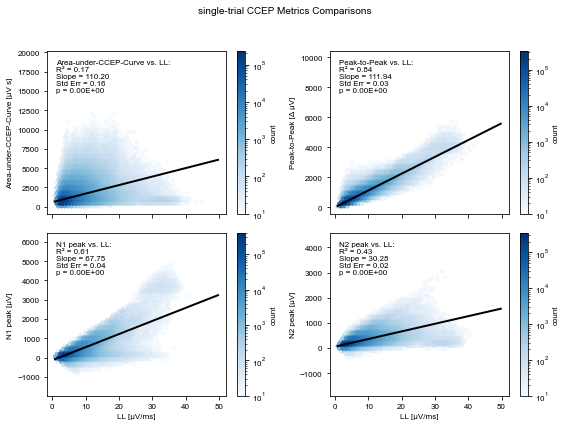

In [229]:
# Create a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()  # Flatten the axes array for easy indexing
plt.suptitle('single-trial CCEP Metrics Comparisons')

for m_ix, metric, m_label, m2_label in zip(np.arange(len(metrics)), metrics, metric_labels, metric_labels2):
    ax = axes[m_ix]
    sample_subset = subset[~np.isnan(subset[metric_x]) & ~np.isnan(subset[metric])]

    # Hexbin plot
    hb = ax.hexbin(sample_subset[metric_x], sample_subset[metric], gridsize=50, cmap='Blues', mincnt=10, bins ='log')
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label('count')

    # Calculate linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(sample_subset[metric_x], sample_subset[metric])

    # Generate regression line x and y values
    x = np.linspace(sample_subset[metric_x].min(), sample_subset[metric_x].max(), 100)
    y = intercept + slope * x

    # Plot the regression line
    ax.plot(x, y, color='k', linewidth=2)

    # Add R² and other stats to the plot
    r_squared = r_value ** 2
    ax.text(0.05, 0.95, f'{m2_label}:\nR² = {r_squared:.2f}\nSlope = {slope:.2f}\nStd Err = {std_err:.2f}\np = {p_value:.2E}', 
            transform=ax.transAxes, ha='left', va='top', fontsize=8)

    ax.set_ylabel(m_label)
    if m_ix >= 2:
        ax.set_xlabel('LL [µV/ms]')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for the suptitle
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\CCEP_magnitude_linReg_hex.svg')
plt.show()

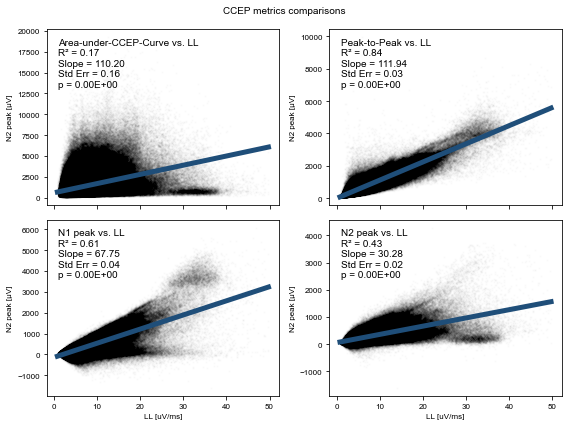

In [223]:

metrics = ['AUC', 'P2P_1s', 'N1', 'N2']
metric_labels = ['Area-under-CCEP-Curve [\u03BCV s]', 'Peak-to-Peak [\u0394 \u03BCV]', 'N1 peak [\u03BCV]', 'N2 peak [\u03BCV]']
metric_labels2 = ['Area-under-CCEP-Curve vs. LL', 'Peak-to-Peak vs. LL', 'N1 peak vs. LL', 'N2 peak vs. LL']

metric_x = 'LL'

# Filter significant connections
subset = con_trial_all[(con_trial_all.zLL_BL<3)&(con_trial_all.zLL<4)&(con_trial_all.LL<50)&(con_trial_all.P2P_1s<10000)&(con_trial_all.AUC<20000)].reset_index(drop=True)
# Create a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex = True)
axes = axes.flatten()  # Flatten the axes array for easy indexing
plt.suptitle('CCEP metrics comparisons')
for m_ix, m, m_labe, m2 in zip(np.arange(len(metrics)), metrics, metric_labels,metric_labels2):
    ax = axes[m_ix]
    
    # Scatter plot a random 5% subset of the data points
    sample_subset = subset[~np.isnan(subset[metric_x])&~np.isnan(subset[m])].reset_index(drop=True)
    ax.scatter(sample_subset[metric_x], sample_subset[m], alpha=0.01, facecolor ='k', s= 2) # , edgecolors='gray'

    # Calculate linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(sample_subset[metric_x], sample_subset[m])

    # Generate regression line x and y values
    x = np.linspace(sample_subset[metric_x].min(), sample_subset[metric_x].max(), 100)
    y = intercept + slope * x

    # Plot the regression line
    ax.plot(x, y, color=color_elab[0], linewidth = 5)

    # Add R² and standard error to the plot
    r_squared = r_value ** 2
    ax.text(0.05, 0.95, m2+ f'\nR² = {r_squared:.2f}\nSlope = {slope:.2f}\nStd Err = {std_err:.2f}\np = {p_value:.2E}', 
            transform=ax.transAxes, ha='left', va='top')
    # ax.set_title(f'Regression of {m} vs {metric_x}')
    #ax.set_title(f'{m_label} vs {metric_x}')
    ax.set_ylabel(m_label)
    if m_ix>1:
        ax.set_xlabel('LL [uV/ms]')

plt.tight_layout()

# plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\CCEP\CCEP_magnitude_linReg_2.png', dpi = 600)
plt.show()


In [230]:
def get_sim(subjs, sub_path):
    # path_export = os.path.join(sub_path,
    #                            'EvM\\Projects\\EL_experiment\Analysis\Patients\Across\BrainMapping\General\data\\')
    start = 1
    for subj in subjs:
        path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
        summary_gen_path = path_patient_analysis + '\\' + folder + '\\' + cond_folder + '\\data\\connectivity_correlation_SleepState.csv'  # summary_general

        con_summary_all = pd.read_csv(summary_gen_path)
        con_summary_all = con_summary_all.drop_duplicates()
        con_summary_all['Subj'] = subj
        if start:
            con_all = con_summary_all
            start = 0
        else:
            con_all = pd.concat([con_all, con_summary_all]).reset_index(drop=True)
    return con_all

In [236]:
subjs = ["EL010", "EL011","EL012","EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022","EL024", "EL026", "EL027", "EL028"]


In [246]:
df = sim_all[sim_all.SleepState!='Wake-MixedSleep'].reset_index(drop=True)

In [ ]:
data_con_file

In [249]:
import statsmodels.formula.api as smf
model = smf.mixedlm("rho ~ Time_diff * SleepState", df, groups=df["Subj"], re_formula="~Time_diff")
result = model.fit()
        #
        # # Print the summary of the model
print(result.summary())
model_summary_latex = result.summary().as_latex()
data_con_file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\BM\Map_similarity.tex'
# Save the LaTeX code to a file
with open(data_con_file, 'w') as f:
    f.write(model_summary_latex)

                   Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       rho       
No. Observations:         11728         Method:                   REML      
No. Groups:               15            Scale:                    0.0019    
Min. group size:          81            Log-Likelihood:           19897.7786
Max. group size:          2346          Converged:                Yes       
Mean group size:          781.9                                             
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          0.876    0.017 52.287 0.000  0.843  0.909
SleepState[T.NREM-NREM]            0.011    0.010  1.164 0.244 -0.008  0.031
SleepState[T.NREM-REM]            -0.030    0.016 -1.845 0.065 -0.062  0.002
SleepState[T.Wake-N

C:\Users\i0328442\AppData\Local\Programs\Python\Python37\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [243]:
sim_all = get_sim(subjs, sub_path)